In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    HistGradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)


In [2]:
!pip install shap

In [3]:
import shap

In [4]:
df = pd.read_csv('CSV.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (7043, 21)


In [5]:
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nTarget Distribution:")
print(df["Churn"].value_counts())

print("\nTarget Percentage:")
print(
    df["Churn"].value_counts(normalize=True) * 100
)



Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate Rows:
0

Target Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Target Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.select_dtypes(include=['int64', 'float64']).columns


Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')

In [8]:
df.select_dtypes(include=['object']).columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')

In [9]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [11]:
df.drop("customerID", axis=1, inplace=True)

In [12]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

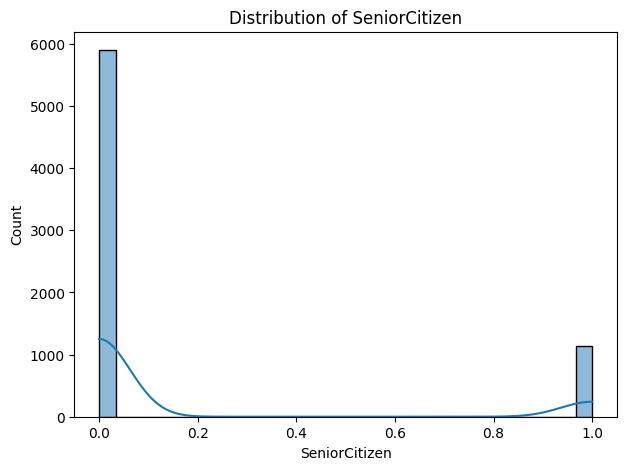

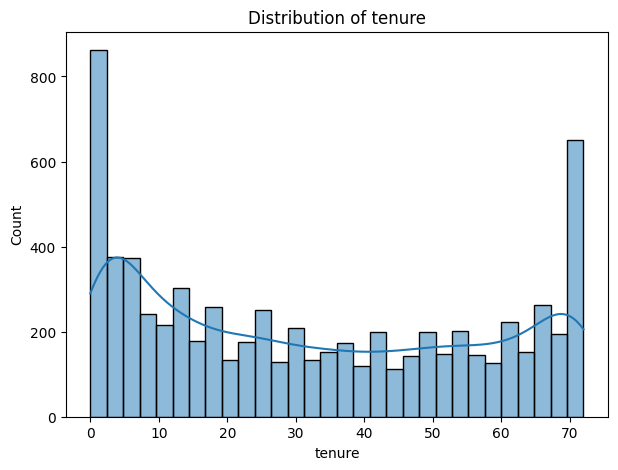

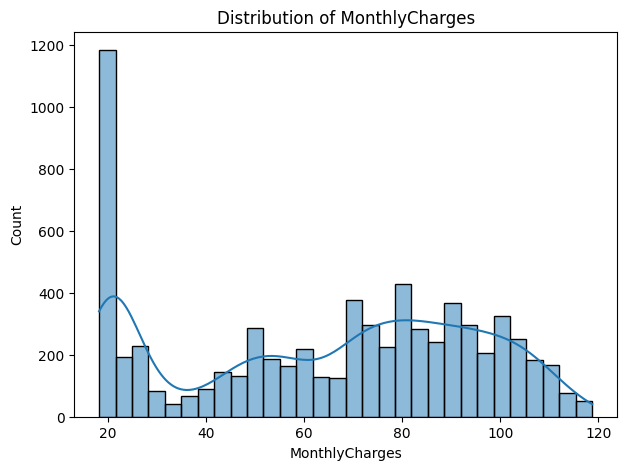

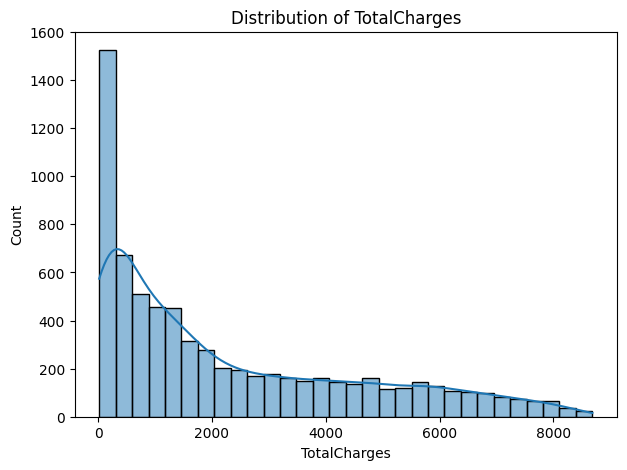

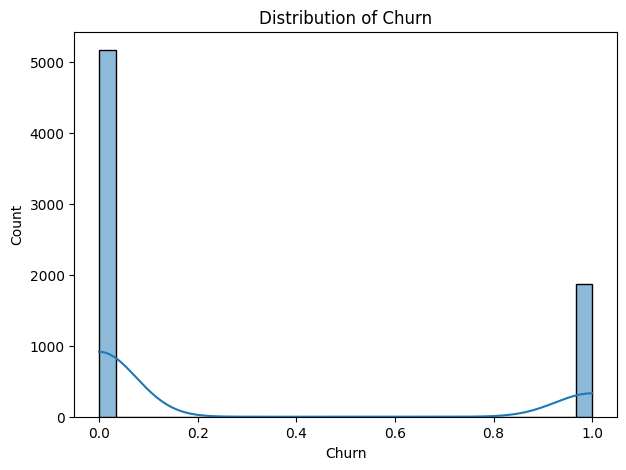

In [13]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

for col in numeric_cols:

    plt.figure(figsize=(7,5))

    sns.histplot(
        df[col].dropna(),
        bins=30,
        kde=True
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.show()

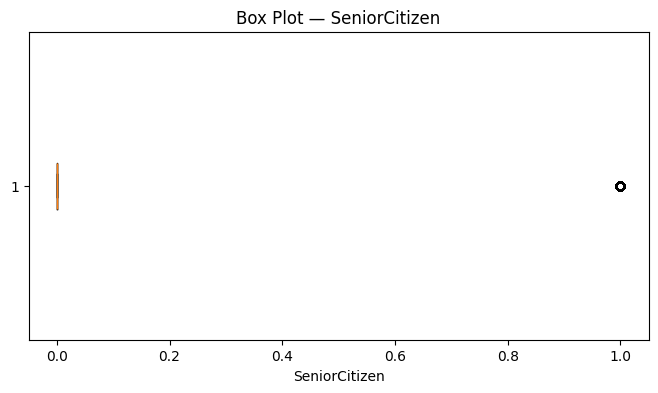

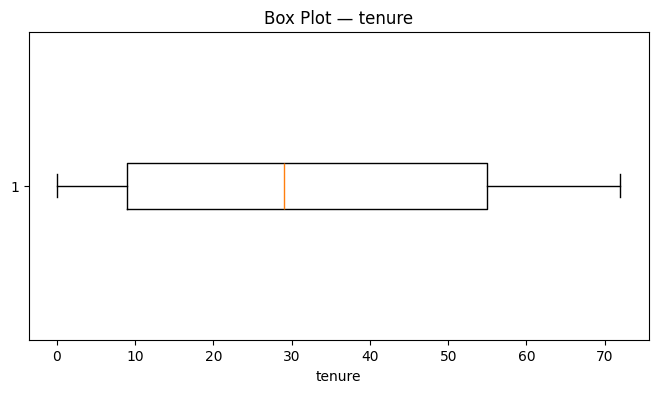

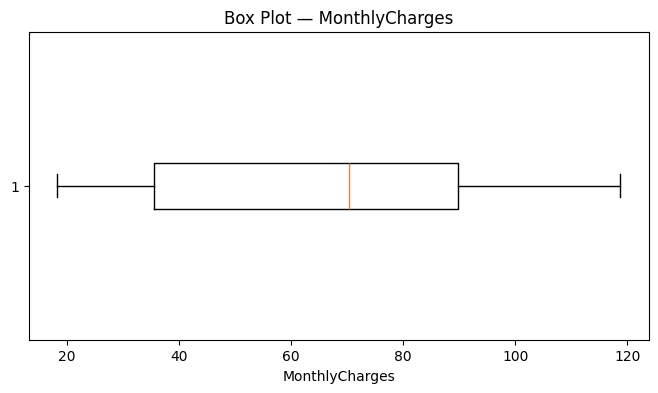

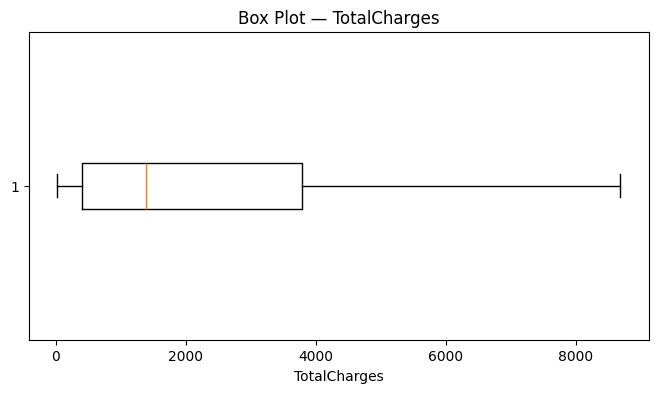

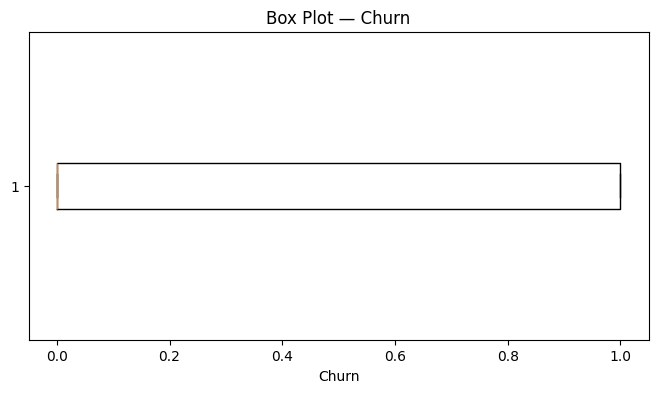

In [14]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns
for col in numeric_cols:

    plt.figure(figsize=(8,4))

    plt.boxplot(
        df[col].dropna(),
        vert=False
    )

    plt.title(f"Box Plot — {col}")
    plt.xlabel(col)

    plt.show()

                SeniorCitizen    tenure  MonthlyCharges  TotalCharges  \
SeniorCitizen        1.000000  0.016567        0.220173      0.102411   
tenure               0.016567  1.000000        0.247900      0.825880   
MonthlyCharges       0.220173  0.247900        1.000000      0.651065   
TotalCharges         0.102411  0.825880        0.651065      1.000000   
Churn                0.150889 -0.352229        0.193356     -0.199484   

                   Churn  
SeniorCitizen   0.150889  
tenure         -0.352229  
MonthlyCharges  0.193356  
TotalCharges   -0.199484  
Churn           1.000000  


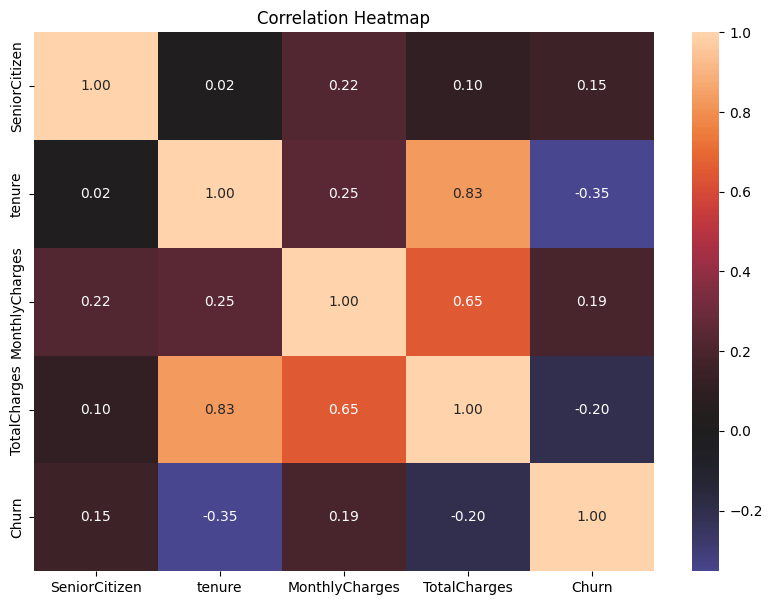

In [15]:
corr = df[numeric_cols].corr()

print(corr)
plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

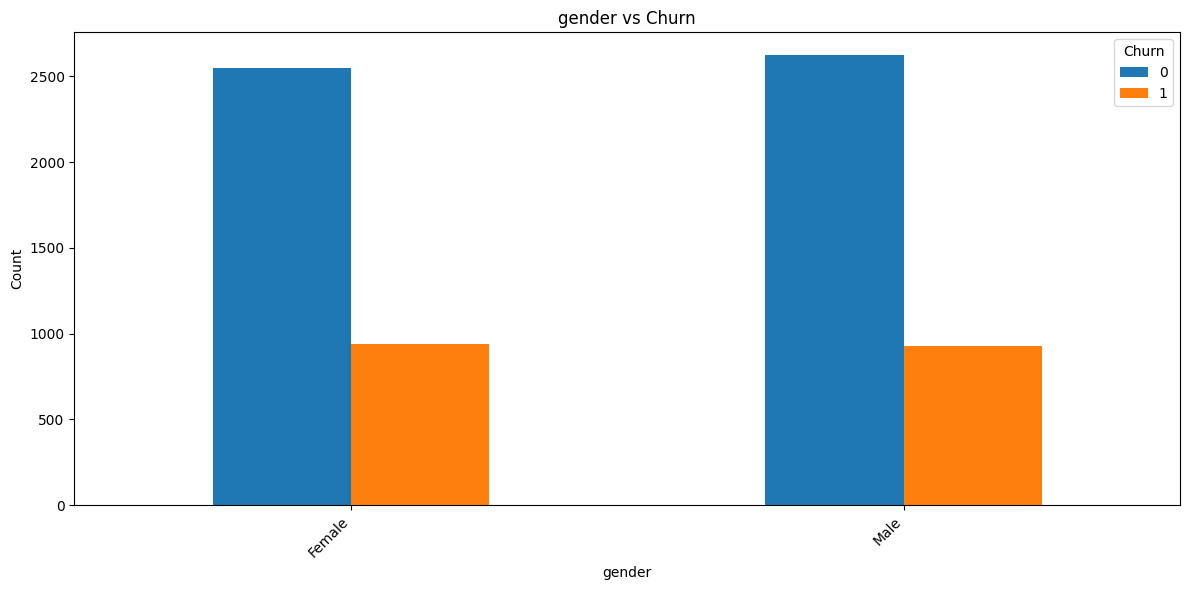

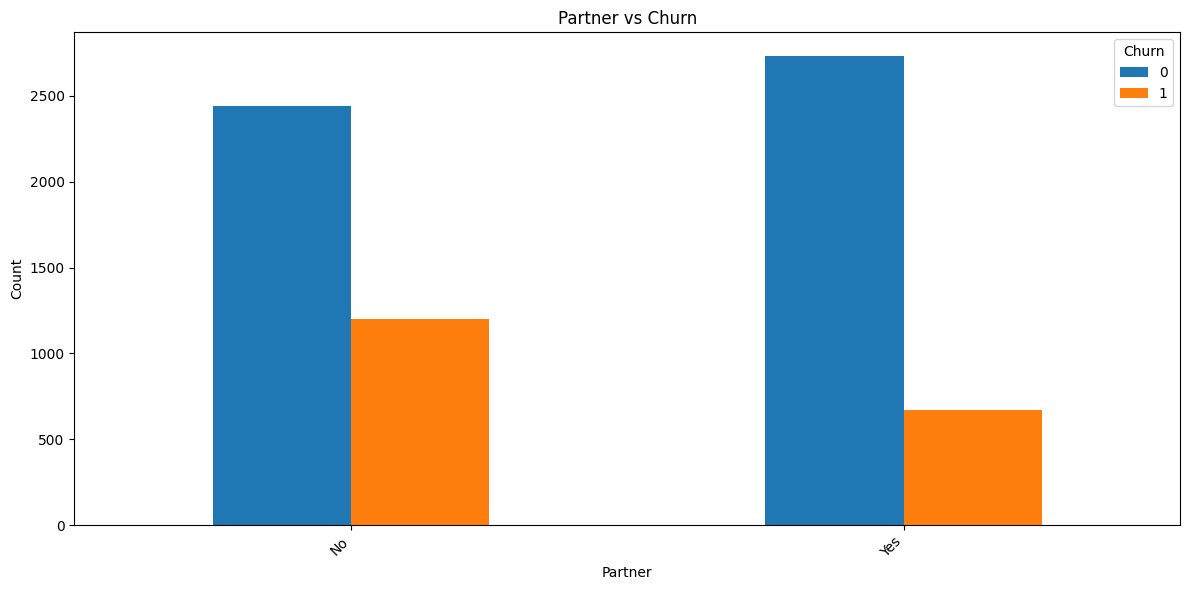

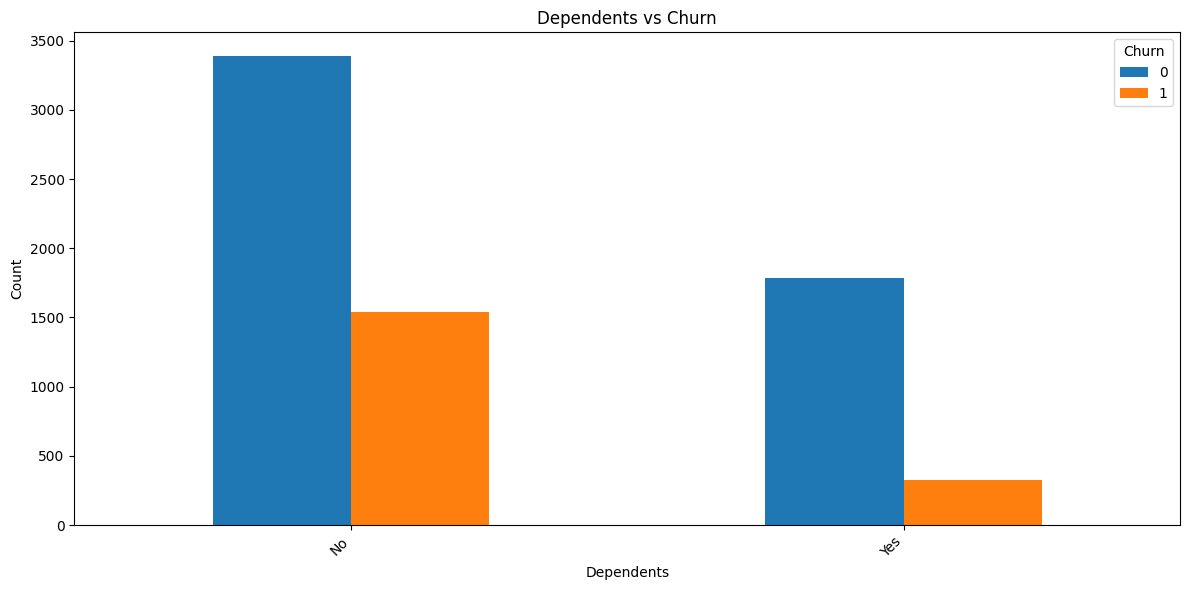

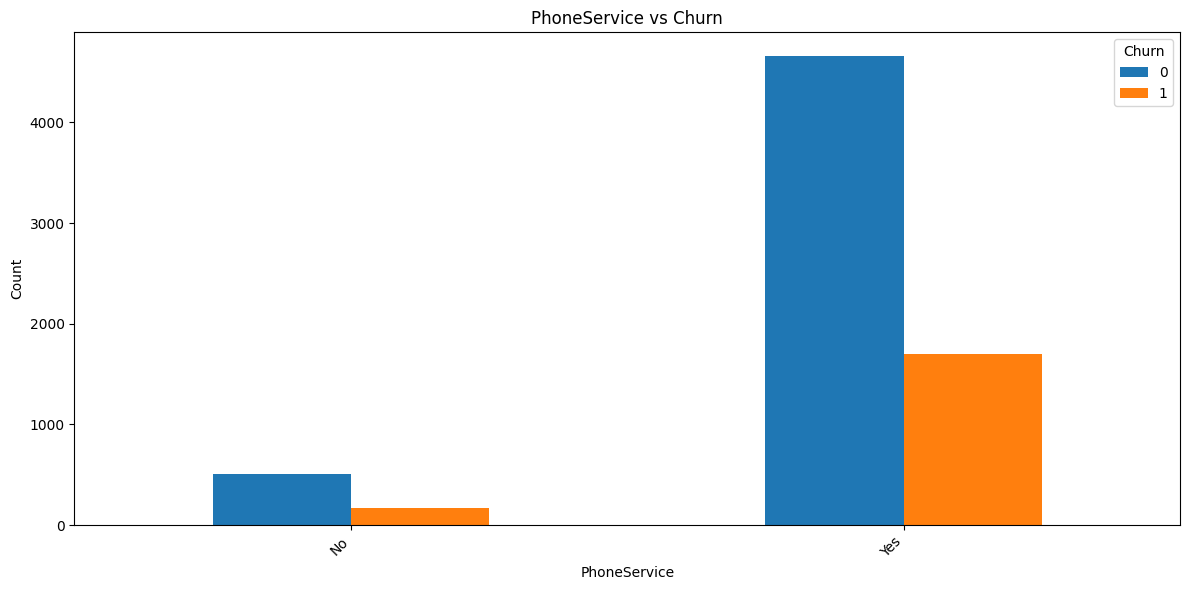

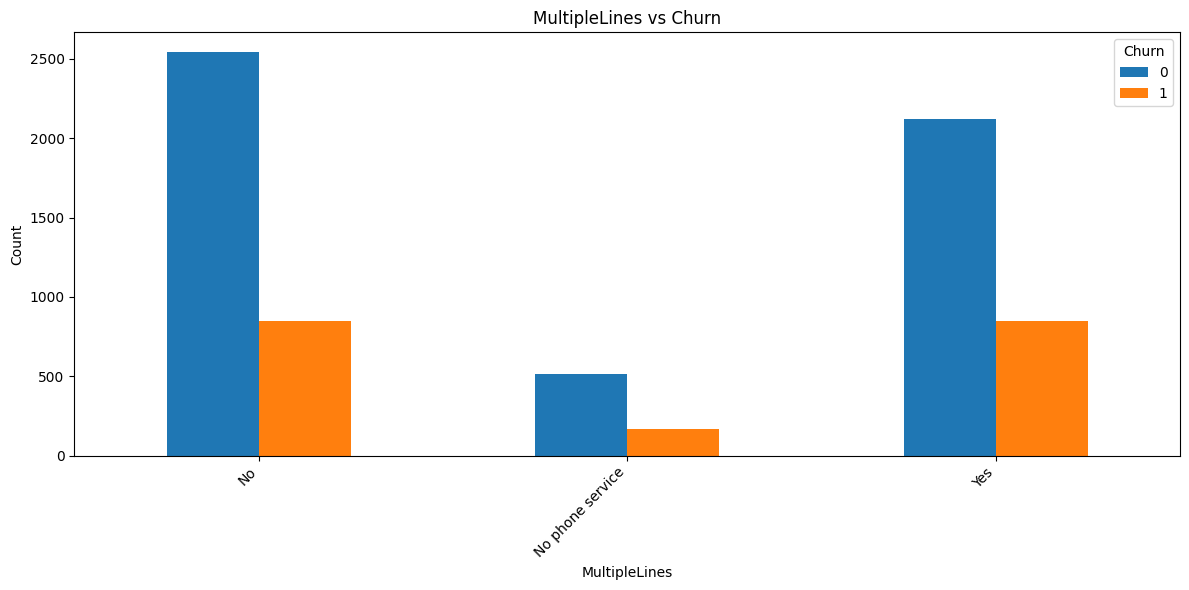

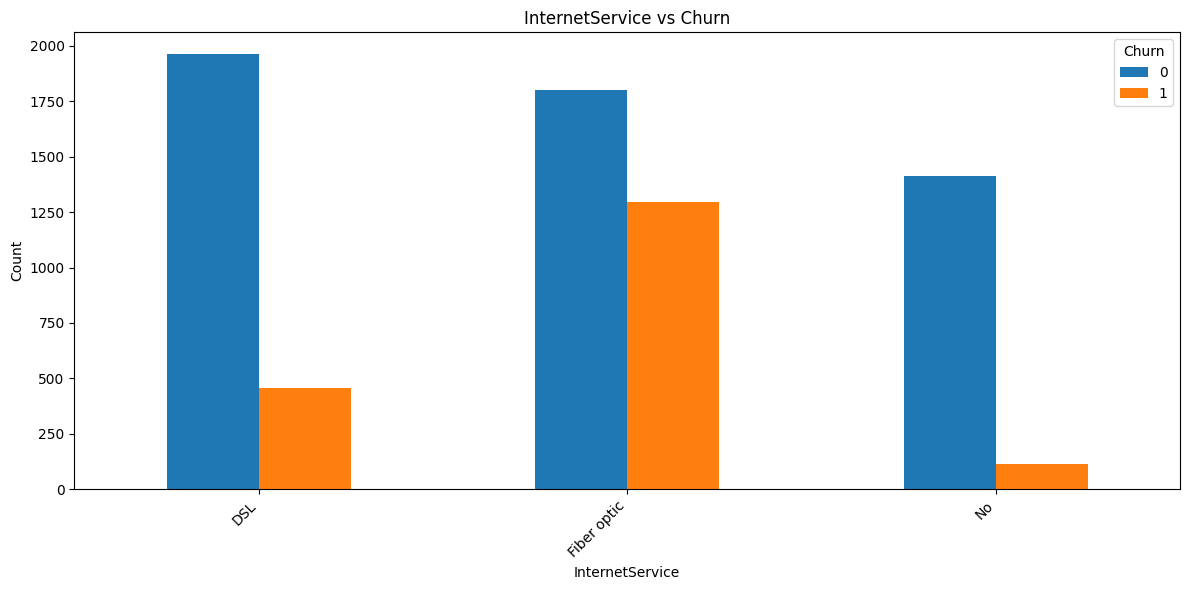

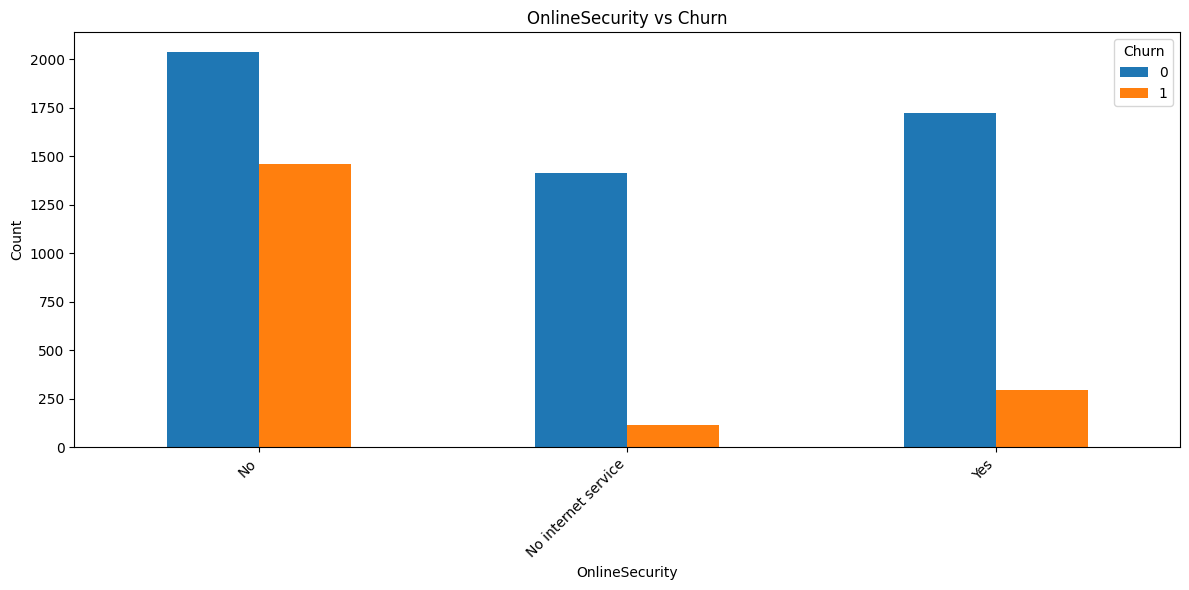

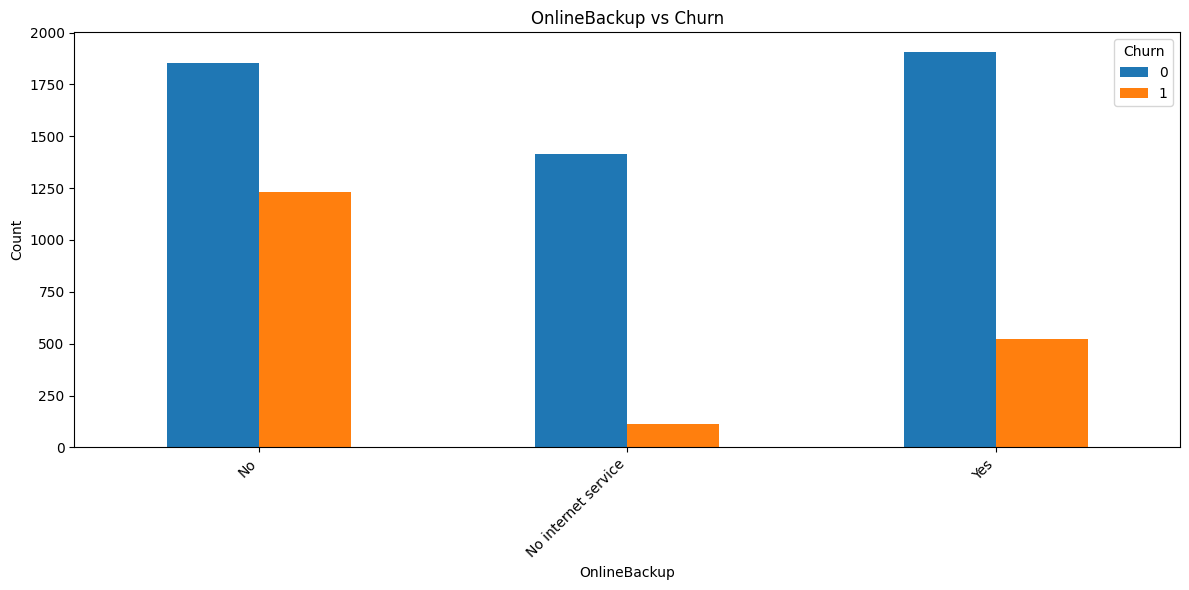

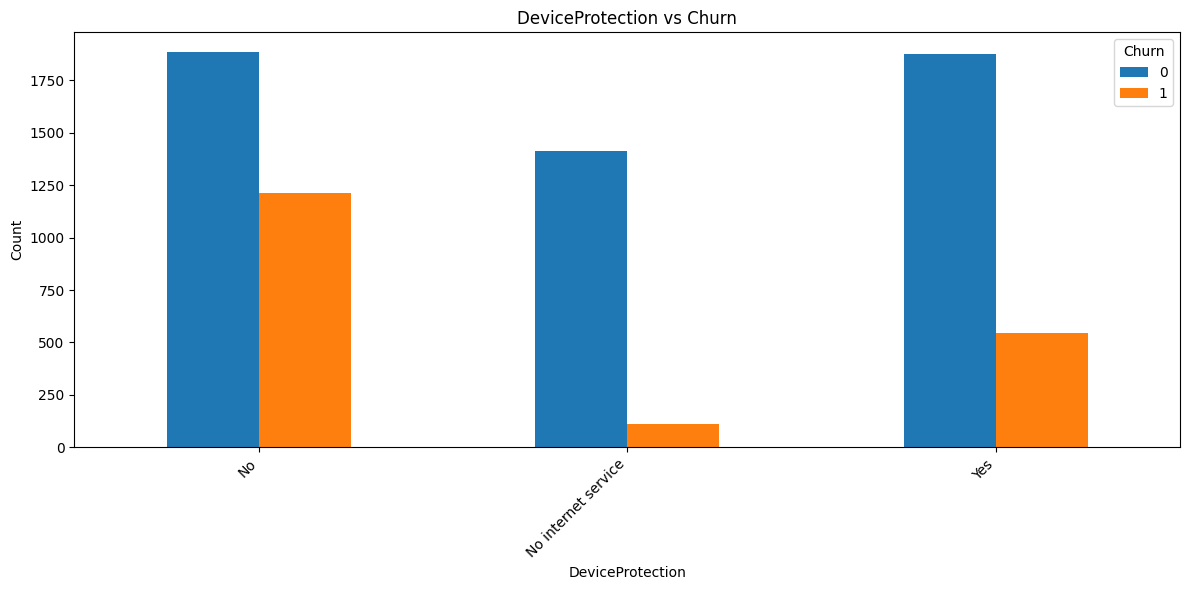

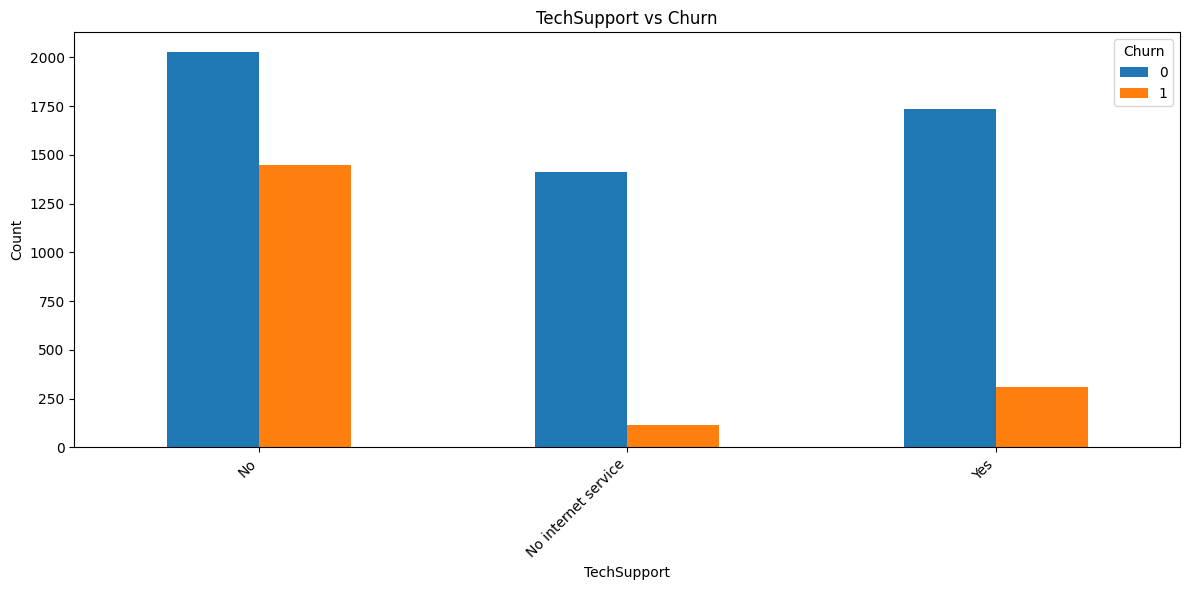

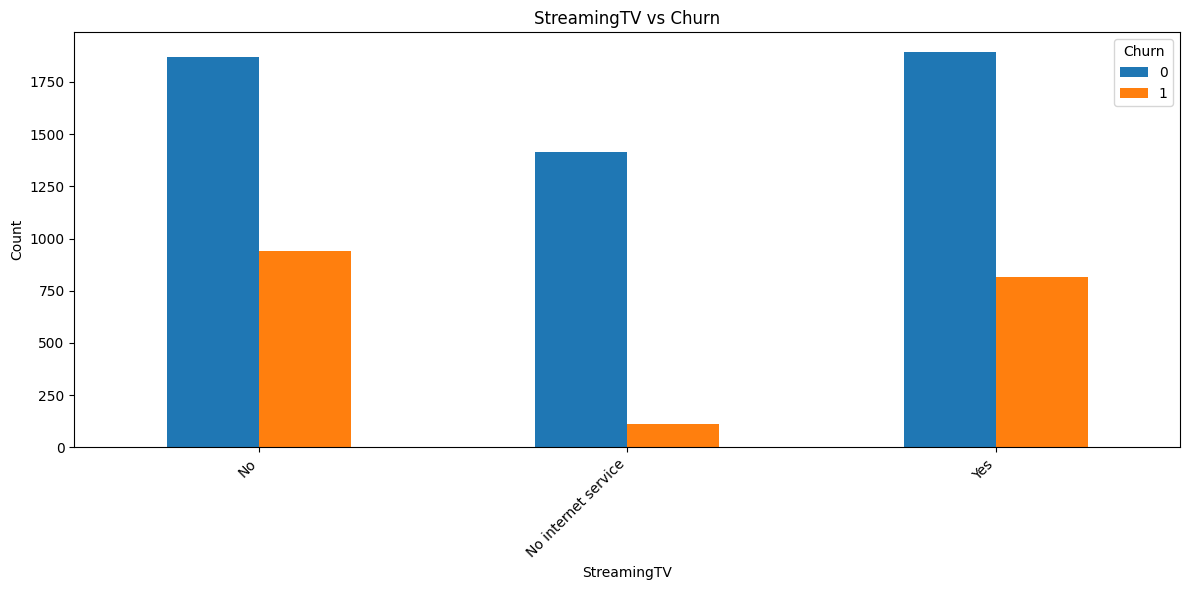

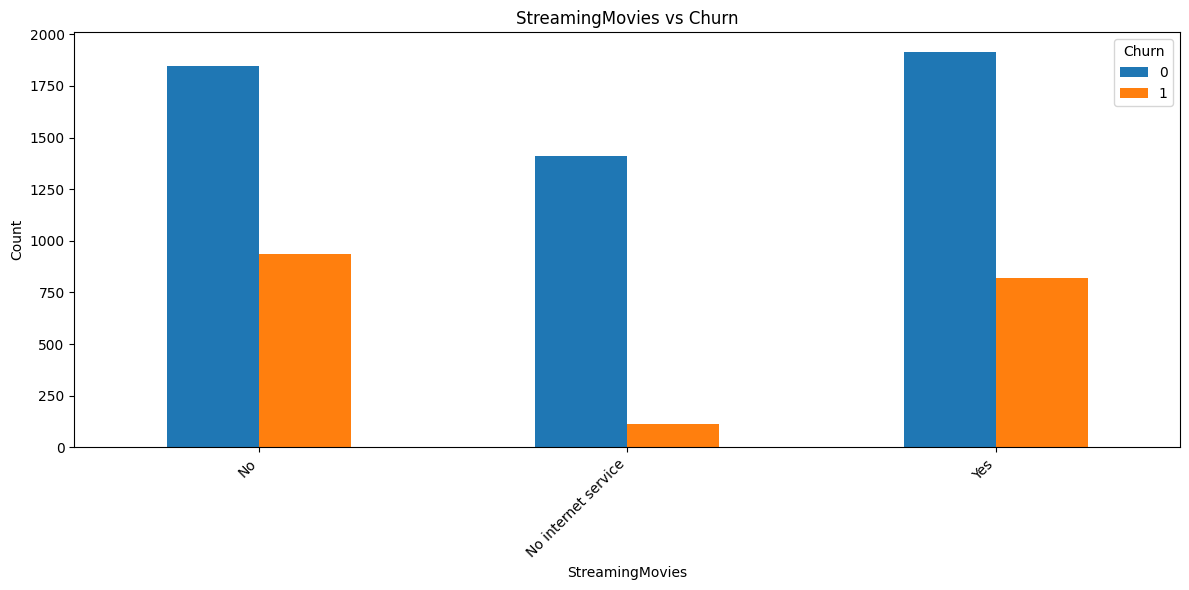

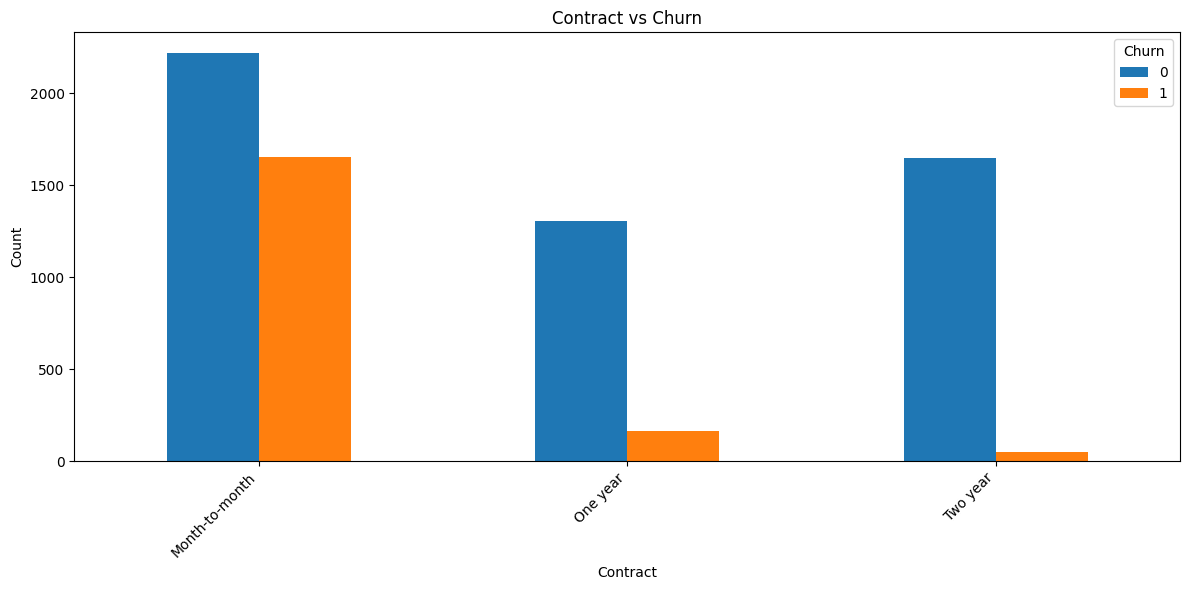

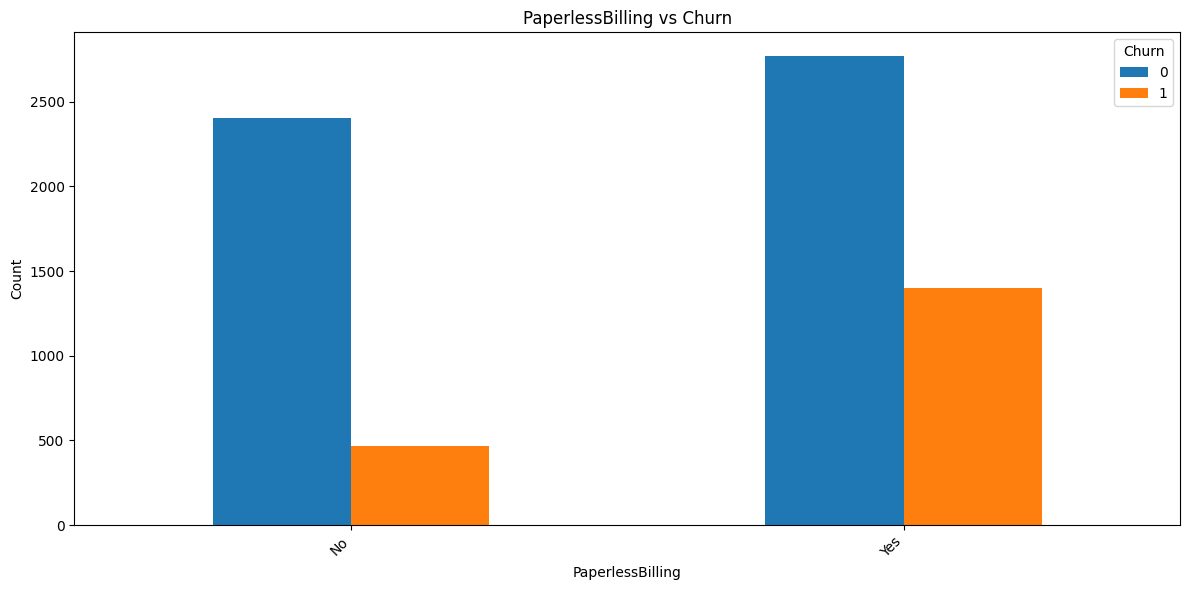

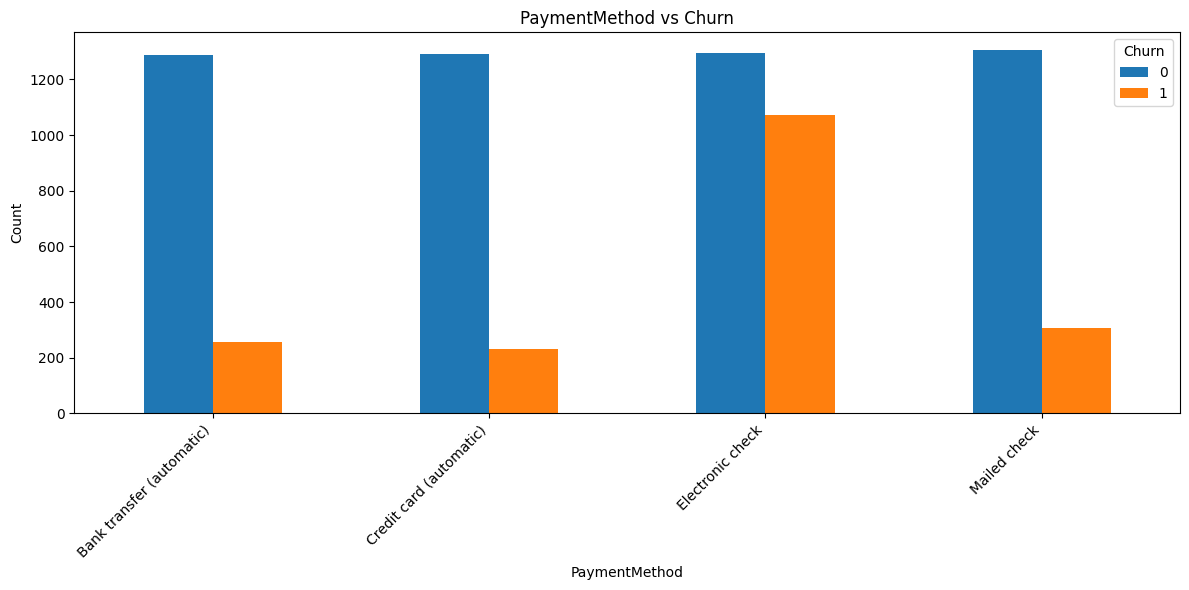

In [18]:
categorical_features = [
    'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'
]

for feature in categorical_features:

    counts = pd.crosstab(
        df[feature],
        df["Churn"] #Traget variable
    )

    counts.plot(
        kind="bar",
        figsize=(12, 6)
    )

    plt.title(f"{feature} vs Churn")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Churn")

    plt.tight_layout()
    plt.show()

In [21]:
# ============================================================
# STEP 4 — FEATURE ANALYSIS & FEATURE SELECTION
# ============================================================

# ------------------------------------------------------------
# 1. Separate features and target
# ------------------------------------------------------------

X = df.drop("Churn", axis=1)
y = df["Churn"]


# ------------------------------------------------------------
# 2. Identify numerical and categorical features
# ------------------------------------------------------------

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("=" * 60)
print("NUMERICAL FEATURES")
print("=" * 60)

print(numeric_features)

print("\nNumber of numerical features:", len(numeric_features))


print("\n" + "=" * 60)
print("CATEGORICAL FEATURES")
print("=" * 60)

print(categorical_features)

print("\nNumber of categorical features:", len(categorical_features))


# ------------------------------------------------------------
# 3. Unique values in categorical columns
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CATEGORICAL FEATURE VALUES")
print("=" * 60)

for column in categorical_features:
    print(f"\n{column}:")
    print(df[column].unique())


# ------------------------------------------------------------
# 4. Numerical summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("NUMERICAL SUMMARY")
print("=" * 60)

display(
    df[numeric_features].describe().T
)


# ------------------------------------------------------------
# 5. Churn rate for every categorical feature
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CHURN RATE BY CATEGORICAL FEATURES")
print("=" * 60)

for column in categorical_features:

    churn_rate = pd.crosstab(
        df[column],
        df["Churn"],
        normalize="index"
    ) * 100

    print(f"\n--- {column} ---")

    display(
        churn_rate.round(2)
    )


# ------------------------------------------------------------
# 6. Numerical features — correlation with churn
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("NUMERICAL FEATURES vs CHURN")
print("=" * 60)

correlations = (
    df[numeric_features + ["Churn"]]
    .corr()["Churn"]
    .drop("Churn")
    .sort_values(key=abs, ascending=False)
)

display(
    correlations.to_frame("Correlation with Churn")
)

NUMERICAL FEATURES
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Number of numerical features: 4

CATEGORICAL FEATURES
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Number of categorical features: 15

CATEGORICAL FEATURE VALUES

gender:
['Female' 'Male']

Partner:
['Yes' 'No']

Dependents:
['No' 'Yes']

PhoneService:
['No' 'Yes']

MultipleLines:
['No phone service' 'No' 'Yes']

InternetService:
['DSL' 'Fiber optic' 'No']

OnlineSecurity:
['No' 'Yes' 'No internet service']

OnlineBackup:
['Yes' 'No' 'No internet service']

DeviceProtection:
['No' 'Yes' 'No internet service']

TechSupport:
['No' 'Yes' 'No internet service']

StreamingTV:
['No' 'Yes' 'No internet service']

StreamingMovies:
['No' 'Yes' 'No internet service']

Contract:
['Month-to-month' 'One year' 'Two year']

Pap

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.000,0.0000,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80



CHURN RATE BY CATEGORICAL FEATURES

--- gender ---


Churn,0,1
gender,,
Female,73.08,26.92
Male,73.84,26.16



--- Partner ---


...

Churn,0,1
PaperlessBilling,,
No,83.67,16.33
Yes,66.43,33.57



--- PaymentMethod ---


Churn,0,1
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11



NUMERICAL FEATURES vs CHURN


,Correlation with Churn
tenure,-0.352229
TotalCharges,-0.199484
MonthlyCharges,0.193356
SeniorCitizen,0.150889


In [22]:
X = df.drop(
    "Churn",
    axis=1
)

y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [23]:
numeric_pipeline = Pipeline([
    
    ("imputer", SimpleImputer(
        strategy="median"
    )),
    
    ("scaler", StandardScaler())
])
categorical_pipeline = Pipeline([
    
    ("imputer", SimpleImputer(
        strategy="most_frequent"
    )),
    
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

In [24]:
preprocessor = ColumnTransformer([
    
    ("numerical",
     numeric_pipeline,
     numeric_features),
    
    ("categorical",
     categorical_pipeline,
     categorical_features)
])

In [25]:

X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

In [26]:
print("\n" + "=" * 60)
print("DATA SPLIT")
print("=" * 60)

print("Training samples :", X_train.shape[0])
print("Testing samples  :", X_test.shape[0])


print("\n" + "=" * 60)
print("PROCESSED DATA")
print("=" * 60)

print("X_train processed shape:",
      X_train_processed.shape)

print("X_test processed shape :",
      X_test_processed.shape)


DATA SPLIT
Training samples : 5634
Testing samples  : 1409

PROCESSED DATA
X_train processed shape: (5634, 45)
X_test processed shape : (1409, 45)


In [27]:
# ------------------------------------------------------------
# 1. Logistic Regression Pipeline
# ------------------------------------------------------------

logistic_model = Pipeline([
    
    ("preprocessor", preprocessor),
    
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])


# ------------------------------------------------------------
# 2. 5-Fold Stratified Cross-Validation
# ------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ------------------------------------------------------------
# 3. Cross-validation scores
# ------------------------------------------------------------

cv_accuracy = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

cv_precision = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring="precision"
)

cv_recall = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring="recall"
)

cv_f1 = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

cv_roc_auc = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)


# ------------------------------------------------------------
# 4. Display results
# ------------------------------------------------------------

print("=" * 60)
print("LOGISTIC REGRESSION — 5-FOLD CROSS-VALIDATION")
print("=" * 60)

print(f"Accuracy  : {cv_accuracy.mean():.4f} ± {cv_accuracy.std():.4f}")
print(f"Precision : {cv_precision.mean():.4f} ± {cv_precision.std():.4f}")
print(f"Recall    : {cv_recall.mean():.4f} ± {cv_recall.std():.4f}")
print(f"F1 Score  : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print(f"ROC-AUC   : {cv_roc_auc.mean():.4f} ± {cv_roc_auc.std():.4f}")

LOGISTIC REGRESSION — 5-FOLD CROSS-VALIDATION
Accuracy  : 0.8021 ± 0.0116
Precision : 0.6529 ± 0.0255
Recall    : 0.5431 ± 0.0411
F1 Score  : 0.5923 ± 0.0296
ROC-AUC   : 0.8461 ± 0.0125


In [28]:
# ------------------------------------------------------------
# 1.  Decision Tree Pipeline
# ------------------------------------------------------------

decision_tree_model = Pipeline([
    
    ("preprocessor", preprocessor),
    
    ("model", DecisionTreeClassifier(
        random_state=42
    ))
])


# ------------------------------------------------------------
# 2. Cross-validation
# ------------------------------------------------------------

dt_accuracy = cross_val_score(
    decision_tree_model,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

dt_precision = cross_val_score(
    decision_tree_model,
    X_train,
    y_train,
    cv=cv,
    scoring="precision"
)

dt_recall = cross_val_score(
    decision_tree_model,
    X_train,
    y_train,
    cv=cv,
    scoring="recall"
)

dt_f1 = cross_val_score(
    decision_tree_model,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

dt_roc_auc = cross_val_score(
    decision_tree_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)


# ------------------------------------------------------------
# 3. Display results
# ------------------------------------------------------------

print("=" * 60)
print("DECISION TREE — 5-FOLD CROSS-VALIDATION")
print("=" * 60)

print(
    f"Accuracy  : {dt_accuracy.mean():.4f} ± "
    f"{dt_accuracy.std():.4f}"
)

print(
    f"Precision : {dt_precision.mean():.4f} ± "
    f"{dt_precision.std():.4f}"
)

print(
    f"Recall    : {dt_recall.mean():.4f} ± "
    f"{dt_recall.std():.4f}"
)

print(
    f"F1 Score  : {dt_f1.mean():.4f} ± "
    f"{dt_f1.std():.4f}"
)

print(
    f"ROC-AUC   : {dt_roc_auc.mean():.4f} ± "
    f"{dt_roc_auc.std():.4f}"
)

DECISION TREE — 5-FOLD CROSS-VALIDATION
Accuracy  : 0.7302 ± 0.0096
Precision : 0.4919 ± 0.0177
Recall    : 0.5057 ± 0.0211
F1 Score  : 0.4986 ± 0.0181
ROC-AUC   : 0.6583 ± 0.0124


In [29]:
# ------------------------------------------------------------
# 1. Random Forest Pipeline
# ------------------------------------------------------------

random_forest_model = Pipeline([
    
    ("preprocessor", preprocessor),
    
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])


# ------------------------------------------------------------
# 2. Cross-validation
# ------------------------------------------------------------

rf_accuracy = cross_val_score(
    random_forest_model,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

rf_precision = cross_val_score(
    random_forest_model,
    X_train,
    y_train,
    cv=cv,
    scoring="precision",
    n_jobs=-1
)

rf_recall = cross_val_score(
    random_forest_model,
    X_train,
    y_train,
    cv=cv,
    scoring="recall",
    n_jobs=-1
)

rf_f1 = cross_val_score(
    random_forest_model,
    X_train,
    y_train,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

rf_roc_auc = cross_val_score(
    random_forest_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)


# ------------------------------------------------------------
# 3. Display results
# ------------------------------------------------------------

print("=" * 60)
print("RANDOM FOREST — 5-FOLD CROSS-VALIDATION")
print("=" * 60)

print(
    f"Accuracy  : {rf_accuracy.mean():.4f} ± "
    f"{rf_accuracy.std():.4f}"
)

print(
    f"Precision : {rf_precision.mean():.4f} ± "
    f"{rf_precision.std():.4f}"
)

print(
    f"Recall    : {rf_recall.mean():.4f} ± "
    f"{rf_recall.std():.4f}"
)

print(
    f"F1 Score  : {rf_f1.mean():.4f} ± "
    f"{rf_f1.std():.4f}"
)

print(
    f"ROC-AUC   : {rf_roc_auc.mean():.4f} ± "
    f"{rf_roc_auc.std():.4f}"
)

RANDOM FOREST — 5-FOLD CROSS-VALIDATION
Accuracy  : 0.7856 ± 0.0124
Precision : 0.6242 ± 0.0333
Recall    : 0.4849 ± 0.0233
F1 Score  : 0.5455 ± 0.0243
ROC-AUC   : 0.8202 ± 0.0128


In [30]:
# ------------------------------------------------------------
# 1. SVM Pipeline
# ------------------------------------------------------------

svm_model = Pipeline([
    
    ("preprocessor", preprocessor),
    
    ("model", SVC(
        kernel="rbf",
        C=1.0,
        probability=True,
        random_state=42
    ))
])


# ------------------------------------------------------------
# 2. Cross-validation
# ------------------------------------------------------------

svm_accuracy = cross_val_score(
    svm_model,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

svm_precision = cross_val_score(
    svm_model,
    X_train,
    y_train,
    cv=cv,
    scoring="precision",
    n_jobs=-1
)

svm_recall = cross_val_score(
    svm_model,
    X_train,
    y_train,
    cv=cv,
    scoring="recall",
    n_jobs=-1
)

svm_f1 = cross_val_score(
    svm_model,
    X_train,
    y_train,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

svm_roc_auc = cross_val_score(
    svm_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)


# ------------------------------------------------------------
# 3. Display results
# ------------------------------------------------------------

print("=" * 60)
print("SVM — 5-FOLD CROSS-VALIDATION")
print("=" * 60)

print(
    f"Accuracy  : {svm_accuracy.mean():.4f} ± "
    f"{svm_accuracy.std():.4f}"
)

print(
    f"Precision : {svm_precision.mean():.4f} ± "
    f"{svm_precision.std():.4f}"
)

print(
    f"Recall    : {svm_recall.mean():.4f} ± "
    f"{svm_recall.std():.4f}"
)

print(
    f"F1 Score  : {svm_f1.mean():.4f} ± "
    f"{svm_f1.std():.4f}"
)

print(
    f"ROC-AUC   : {svm_roc_auc.mean():.4f} ± "
    f"{svm_roc_auc.std():.4f}"
)

SVM — 5-FOLD CROSS-VALIDATION
Accuracy  : 0.8035 ± 0.0088
Precision : 0.6772 ± 0.0276
Recall    : 0.4977 ± 0.0157
F1 Score  : 0.5735 ± 0.0162
ROC-AUC   : 0.7998 ± 0.0160


In [31]:
# ------------------------------------------------------------
# 1. Gradient Boosting Pipeline
# ------------------------------------------------------------

gradient_boosting_model = Pipeline([
    
    ("preprocessor", preprocessor),
    
    ("model", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])


# ------------------------------------------------------------
# 2. Cross-validation
# ------------------------------------------------------------

gb_accuracy = cross_val_score(
    gradient_boosting_model,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

gb_precision = cross_val_score(
    gradient_boosting_model,
    X_train,
    y_train,
    cv=cv,
    scoring="precision",
    n_jobs=-1
)

gb_recall = cross_val_score(
    gradient_boosting_model,
    X_train,
    y_train,
    cv=cv,
    scoring="recall",
    n_jobs=-1
)

gb_f1 = cross_val_score(
    gradient_boosting_model,
    X_train,
    y_train,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

gb_roc_auc = cross_val_score(
    gradient_boosting_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)


# ------------------------------------------------------------
# 3. Display results
# ------------------------------------------------------------

print("=" * 60)
print("GRADIENT BOOSTING — 5-FOLD CROSS-VALIDATION")
print("=" * 60)

print(
    f"Accuracy  : {gb_accuracy.mean():.4f} ± "
    f"{gb_accuracy.std():.4f}"
)

print(
    f"Precision : {gb_precision.mean():.4f} ± "
    f"{gb_precision.std():.4f}"
)

print(
    f"Recall    : {gb_recall.mean():.4f} ± "
    f"{gb_recall.std():.4f}"
)

print(
    f"F1 Score  : {gb_f1.mean():.4f} ± "
    f"{gb_f1.std():.4f}"
)

print(
    f"ROC-AUC   : {gb_roc_auc.mean():.4f} ± "
    f"{gb_roc_auc.std():.4f}"
)

GRADIENT BOOSTING — 5-FOLD CROSS-VALIDATION
Accuracy  : 0.8033 ± 0.0110
Precision : 0.6606 ± 0.0289
Recall    : 0.5338 ± 0.0234
F1 Score  : 0.5902 ± 0.0227
ROC-AUC   : 0.8478 ± 0.0122


In [32]:
# ============================================================
#  MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame({
    
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "Gradient Boosting"
    ],
    
    "Accuracy": [
        cv_accuracy.mean(),
        dt_accuracy.mean(),
        rf_accuracy.mean(),
        svm_accuracy.mean(),
        gb_accuracy.mean()
    ],
    
    "Precision": [
        cv_precision.mean(),
        dt_precision.mean(),
        rf_precision.mean(),
        svm_precision.mean(),
        gb_precision.mean()
    ],
    
    "Recall": [
        cv_recall.mean(),
        dt_recall.mean(),
        rf_recall.mean(),
        svm_recall.mean(),
        gb_recall.mean()
    ],
    
    "F1 Score": [
        cv_f1.mean(),
        dt_f1.mean(),
        rf_f1.mean(),
        svm_f1.mean(),
        gb_f1.mean()
    ],
    
    "ROC-AUC": [
        cv_roc_auc.mean(),
        dt_roc_auc.mean(),
        rf_roc_auc.mean(),
        svm_roc_auc.mean(),
        gb_roc_auc.mean()
    ]
})


# ------------------------------------------------------------
# Sort by ROC-AUC
# ------------------------------------------------------------

comparison = comparison.sort_values(
    "ROC-AUC",
    ascending=False
).reset_index(drop=True)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 75)
print("MODEL COMPARISON — 5-FOLD CROSS-VALIDATION")
print("=" * 75)

display(
    comparison.round(4)
)

MODEL COMPARISON — 5-FOLD CROSS-VALIDATION


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting,0.8033,0.6606,0.5338,0.5902,0.8478
1,Logistic Regression,0.8021,0.6529,0.5431,0.5923,0.8461
2,Random Forest,0.7856,0.6242,0.4849,0.5455,0.8202
3,SVM,0.8035,0.6772,0.4977,0.5735,0.7998
4,Decision Tree,0.7302,0.4919,0.5057,0.4986,0.6583


In [33]:
# ============================================================
#  HYPERPARAMETER TUNING
# TEST SET STILL UNTOUCHED
# ============================================================

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, loguniform, randint


# ============================================================
# 1. LOGISTIC REGRESSION
# ============================================================

logistic_pipeline = Pipeline([
    
    ("preprocessor", preprocessor),
    
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])


# Hyperparameters to search
logistic_params = {
    
    "model__C": loguniform(0.001, 100),
    
    "model__class_weight": [
        None,
        "balanced"
    ],
    
    "model__solver": [
        "liblinear",
        "lbfgs"
    ]
}


logistic_search = RandomizedSearchCV(
    
    estimator=logistic_pipeline,
    
    param_distributions=logistic_params,
    
    n_iter=20,
    
    scoring="roc_auc",
    
    cv=cv,
    
    random_state=42,
    
    n_jobs=-1,
    
    verbose=1
)


print("=" * 70)
print("TUNING LOGISTIC REGRESSION")
print("=" * 70)


logistic_search.fit(
    X_train,
    y_train
)


print("\nBest Logistic Regression Parameters:")
print(logistic_search.best_params_)

print(
    f"\nBest Logistic Regression CV ROC-AUC: "
    f"{logistic_search.best_score_:.4f}"
)


# ============================================================
# 2. GRADIENT BOOSTING
# ============================================================

gradient_pipeline = Pipeline([
    
    ("preprocessor", preprocessor),
    
    ("model", GradientBoostingClassifier(
        random_state=42
    ))
])


# Hyperparameters to search
gradient_params = {
    
    "model__n_estimators": randint(50, 300),
    
    "model__learning_rate": uniform(0.01, 0.19),
    
    "model__max_depth": randint(2, 6),
    
    "model__min_samples_split": randint(2, 20),
    
    "model__min_samples_leaf": randint(1, 10),
    
    "model__subsample": uniform(0.7, 0.3)
}


gradient_search = RandomizedSearchCV(
    
    estimator=gradient_pipeline,
    
    param_distributions=gradient_params,
    
    n_iter=30,
    
    scoring="roc_auc",
    
    cv=cv,
    
    random_state=42,
    
    n_jobs=-1,
    
    verbose=1
)


print("\n" + "=" * 70)
print("TUNING GRADIENT BOOSTING")
print("=" * 70)


gradient_search.fit(
    X_train,
    y_train
)


print("\nBest Gradient Boosting Parameters:")
print(gradient_search.best_params_)

print(
    f"\nBest Gradient Boosting CV ROC-AUC: "
    f"{gradient_search.best_score_:.4f}"
)


# ============================================================
# 3. COMPARE TUNED MODELS
# ============================================================

tuned_comparison = pd.DataFrame({
    
    "Model": [
        "Tuned Logistic Regression",
        "Tuned Gradient Boosting"
    ],
    
    "CV ROC-AUC": [
        logistic_search.best_score_,
        gradient_search.best_score_
    ]
})


tuned_comparison = tuned_comparison.sort_values(
    "CV ROC-AUC",
    ascending=False
).reset_index(drop=True)


print("\n" + "=" * 70)
print("TUNED MODEL COMPARISON")
print("=" * 70)

display(
    tuned_comparison.round(4)
)

TUNING LOGISTIC REGRESSION
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Logistic Regression Parameters:
{'model__C': np.float64(4.5705630998014515), 'model__class_weight': None, 'model__solver': 'liblinear'}

Best Logistic Regression CV ROC-AUC: 0.8463

TUNING GRADIENT BOOSTING
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Gradient Boosting Parameters:
{'model__learning_rate': np.float64(0.06411969393171885), 'model__max_depth': 2, 'model__min_samples_leaf': 1, 'model__min_samples_split': 3, 'model__n_estimators': 179, 'model__subsample': np.float64(0.8233111039954694)}

Best Gradient Boosting CV ROC-AUC: 0.8509

TUNED MODEL COMPARISON


,Model,CV ROC-AUC
0,Tuned Gradient Boosting,0.8509
1,Tuned Logistic Regression,0.8463


THRESHOLD TUNING RESULTS
Best Threshold : 0.34
Accuracy       : 0.7879
Precision      : 0.5801
Recall         : 0.7264
F1 Score       : 0.6451

TOP THRESHOLDS BY F1 SCORE


,Threshold,Accuracy,Precision,Recall,F1
14,0.34,0.7879,0.5801,0.7264,0.6451
13,0.33,0.7835,0.5712,0.7378,0.6439
16,0.36,0.7930,0.5928,0.7030,0.6432
15,0.35,0.7900,0.5859,0.7117,0.6427
12,0.32,0.7772,0.5602,0.7465,0.6401
11,0.31,0.7742,0.5548,0.7552,0.6397
10,0.30,0.7693,0.5468,0.7619,0.6367
8,0.28,0.7622,0.5354,0.7846,0.6365
17,0.37,0.7923,0.5944,0.6843,0.6362
9,0.29,0.7645,0.5391,0.7746,0.6357


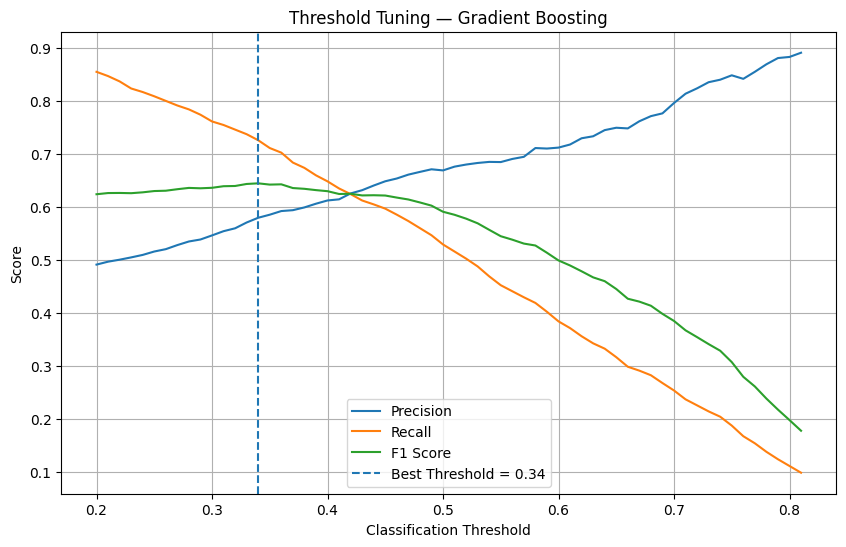

In [34]:
# ============================================================
# THRESHOLD TUNING
# ============================================================

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Get OUT-OF-FOLD probabilities
# ------------------------------------------------------------

oof_probabilities = cross_val_predict(
    gradient_search.best_estimator_,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]


# ------------------------------------------------------------
# 2. Test different thresholds
# ------------------------------------------------------------

threshold_results = []

thresholds = np.arange(
    0.20,
    0.81,
    0.01
)


for threshold in thresholds:

    y_pred_threshold = (
        oof_probabilities >= threshold
    ).astype(int)

    threshold_results.append({

        "Threshold": threshold,

        "Accuracy": accuracy_score(
            y_train,
            y_pred_threshold
        ),

        "Precision": precision_score(
            y_train,
            y_pred_threshold,
            zero_division=0
        ),

        "Recall": recall_score(
            y_train,
            y_pred_threshold,
            zero_division=0
        ),

        "F1": f1_score(
            y_train,
            y_pred_threshold,
            zero_division=0
        )
    })


threshold_results = pd.DataFrame(
    threshold_results
)


# ------------------------------------------------------------
# 3. Find threshold with highest F1
# ------------------------------------------------------------

best_threshold_row = threshold_results.loc[
    threshold_results["F1"].idxmax()
]


best_threshold = best_threshold_row["Threshold"]


# ------------------------------------------------------------
# 4. Display best threshold
# ------------------------------------------------------------

print("=" * 70)
print("THRESHOLD TUNING RESULTS")
print("=" * 70)

print(
    f"Best Threshold : {best_threshold:.2f}"
)

print(
    f"Accuracy       : "
    f"{best_threshold_row['Accuracy']:.4f}"
)

print(
    f"Precision      : "
    f"{best_threshold_row['Precision']:.4f}"
)

print(
    f"Recall         : "
    f"{best_threshold_row['Recall']:.4f}"
)

print(
    f"F1 Score       : "
    f"{best_threshold_row['F1']:.4f}"
)


# ------------------------------------------------------------
# 5. Display top thresholds
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TOP THRESHOLDS BY F1 SCORE")
print("=" * 70)

display(
    threshold_results
    .sort_values("F1", ascending=False)
    .head(10)
    .round(4)
)


# ------------------------------------------------------------
# 6. Plot threshold performance
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1"],
    label="F1 Score"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best Threshold = {best_threshold:.2f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title(
    "Threshold Tuning — Gradient Boosting"
)

plt.legend()
plt.grid(True)

plt.show()                                                                                                      

In [35]:
# ============================================================
# ERROR ANALYSIS
# ============================================================

# ------------------------------------------------------------
# 1. Apply our selected threshold
# ------------------------------------------------------------

oof_predictions = (
    oof_probabilities >= best_threshold
).astype(int)


# ------------------------------------------------------------
# 2. Create error-analysis dataframe
# ------------------------------------------------------------

error_analysis = X_train.copy()

error_analysis["Actual"] = y_train.values

error_analysis["Predicted_Probability"] = oof_probabilities

error_analysis["Predicted"] = oof_predictions


# ------------------------------------------------------------
# 3. Identify error types
# ------------------------------------------------------------

error_analysis["Error_Type"] = "Correct"

error_analysis.loc[
    (error_analysis["Actual"] == 0) &
    (error_analysis["Predicted"] == 1),
    "Error_Type"
] = "False Positive"

error_analysis.loc[
    (error_analysis["Actual"] == 1) &
    (error_analysis["Predicted"] == 0),
    "Error_Type"
] = "False Negative"


# ------------------------------------------------------------
# 4. Error summary
# ------------------------------------------------------------

print("=" * 70)
print("ERROR ANALYSIS")
print("=" * 70)

print(
    error_analysis["Error_Type"]
    .value_counts()
)


# ------------------------------------------------------------
# 5. Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    error_analysis["Actual"],
    error_analysis["Predicted"]
)

print("\nConfusion Matrix:")
print(cm)


# ------------------------------------------------------------
# 6. Display error percentages
# ------------------------------------------------------------

total = len(error_analysis)

false_positive_count = (
    error_analysis["Error_Type"] == "False Positive"
).sum()

false_negative_count = (
    error_analysis["Error_Type"] == "False Negative"
).sum()

correct_count = (
    error_analysis["Error_Type"] == "Correct"
).sum()


print("\n" + "=" * 70)
print("ERROR SUMMARY")
print("=" * 70)

print(
    f"Correct predictions : {correct_count} "
    f"({correct_count / total:.2%})"
)

print(
    f"False positives     : {false_positive_count} "
    f"({false_positive_count / total:.2%})"
)

print(
    f"False negatives     : {false_negative_count} "
    f"({false_negative_count / total:.2%})"
)


# ------------------------------------------------------------
# 7. Show false positives
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FALSE POSITIVES — Predicted Churn, Actually No Churn")
print("=" * 70)

display(
    error_analysis[
        error_analysis["Error_Type"] == "False Positive"
    ]
    .sort_values(
        "Predicted_Probability",
        ascending=False
    )
    .head(10)
)


# ------------------------------------------------------------
# 8. Show false negatives
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FALSE NEGATIVES — Predicted No Churn, Actually Churn")
print("=" * 70)

display(
    error_analysis[
        error_analysis["Error_Type"] == "False Negative"
    ]
    .sort_values(
        "Predicted_Probability",
        ascending=True
    )
    .head(10)
)

ERROR ANALYSIS
Error_Type
Correct           4439
False Positive     786
False Negative     409
Name: count, dtype: int64

Confusion Matrix:
[[3353  786]
 [ 409 1086]]

ERROR SUMMARY
Correct predictions : 4439 (78.79%)
False positives     : 786 (13.95%)
False negatives     : 409 (7.26%)

FALSE POSITIVES — Predicted Churn, Actually No Churn


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual,Predicted_Probability,Predicted,Error_Type
1095,Male,0,No,No,1,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,80.55,80.55,0,0.893653,1,False Positive
1929,Male,0,Yes,Yes,1,Yes,No,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,81.05,81.05,0,0.892644,1,False Positive
5474,Female,0,No,No,1,Yes,Yes,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,84.60,84.60,0,0.888800,1,False Positive
5140,Male,0,No,No,1,Yes,No,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,89.25,89.25,0,0.884336,1,False Positive
3159,Male,1,No,No,3,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,94.85,335.75,0,0.882799,1,False Positive
5354,Female,0,No,Yes,1,Yes,No,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,89.35,89.35,0,0.881198,1,False Positive
345,Female,1,No,No,1,Yes,Yes,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,72.10,72.10,0,0.880882,1,False Positive
459,Male,0,No,No,1,Yes,Yes,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,75.10,75.10,0,0.864712,1,False Positive
5307,Male,0,Yes,Yes,1,Yes,No,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,90.10,90.10,0,0.852256,1,False Positive
3633,Female,1,No,No,1,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,71.25,71.25,0,0.846724,1,False Positive



FALSE NEGATIVES — Predicted No Churn, Actually Churn


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual,Predicted_Probability,Predicted,Error_Type
4272,Male,0,Yes,No,56,Yes,Yes,No,No internet service,No internet service,...,No internet service,Two year,Yes,Credit card (automatic),25.15,1327.15,1,0.017281,0,False Negative
268,Male,0,No,No,59,Yes,No,No,No internet service,No internet service,...,No internet service,Two year,No,Mailed check,19.35,1099.60,1,0.018186,0,False Negative
4819,Male,0,No,Yes,53,Yes,No,No,No internet service,No internet service,...,No internet service,Two year,No,Bank transfer (automatic),19.75,1052.35,1,0.018669,0,False Negative
6724,Female,1,No,No,64,Yes,No,DSL,Yes,Yes,...,No,Two year,Yes,Credit card (automatic),70.20,4481.00,1,0.018832,0,False Negative
5441,Female,0,Yes,No,70,Yes,Yes,DSL,Yes,No,...,No,Two year,No,Credit card (automatic),65.30,4759.75,1,0.020400,0,False Negative
3779,Male,1,Yes,Yes,66,Yes,Yes,DSL,Yes,Yes,...,No,Two year,No,Credit card (automatic),79.40,5154.60,1,0.021255,0,False Negative
5579,Female,0,Yes,Yes,70,Yes,Yes,Fiber optic,Yes,Yes,...,No,Two year,No,Bank transfer (automatic),93.90,6579.05,1,0.021734,0,False Negative
3971,Female,0,No,No,25,Yes,Yes,No,No internet service,No internet service,...,No internet service,Two year,No,Credit card (automatic),24.75,692.10,1,0.022505,0,False Negative
5947,Female,0,Yes,Yes,33,Yes,Yes,No,No internet service,No internet service,...,No internet service,Two year,Yes,Mailed check,24.50,740.30,1,0.022874,0,False Negative
4642,Male,0,Yes,Yes,65,Yes,No,DSL,Yes,No,...,Yes,Two year,Yes,Bank transfer (automatic),74.80,4820.15,1,0.024151,0,False Negative


In [36]:
# ============================================================
# FINAL TEST SET EVALUATION

# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# 1. Final model
# ------------------------------------------------------------

final_model = gradient_search.best_estimator_


# ------------------------------------------------------------
# 2. Predict probabilities on TEST SET
# ------------------------------------------------------------

test_probabilities = final_model.predict_proba(
    X_test
)[:, 1]


# ------------------------------------------------------------
# 3. Apply our previously selected threshold
# ------------------------------------------------------------

test_predictions = (
    test_probabilities >= best_threshold
).astype(int)


# ------------------------------------------------------------
# 4. Calculate FINAL test metrics
# ------------------------------------------------------------

test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

test_precision = precision_score(
    y_test,
    test_predictions,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    test_predictions,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    test_predictions,
    zero_division=0
)

test_roc_auc = roc_auc_score(
    y_test,
    test_probabilities
)


# ------------------------------------------------------------
# 5. Display FINAL RESULTS
# ------------------------------------------------------------

print("=" * 70)
print("FINAL TEST SET RESULTS")
print("=" * 70)

print(f"Model              : Gradient Boosting")
print(f"Threshold          : {best_threshold:.2f}")
print(f"Accuracy           : {test_accuracy:.4f}")
print(f"Precision          : {test_precision:.4f}")
print(f"Recall             : {test_recall:.4f}")
print(f"F1 Score           : {test_f1:.4f}")
print(f"ROC-AUC            : {test_roc_auc:.4f}")


# ------------------------------------------------------------
# 6. Confusion Matrix
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL TEST CONFUSION MATRIX")
print("=" * 70)

final_cm = confusion_matrix(
    y_test,
    test_predictions
)

print(final_cm)


# ------------------------------------------------------------
# 7. Classification Report
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        test_predictions,
        target_names=[
            "No Churn",
            "Churn"
        ],
        zero_division=0
    )
)

FINAL TEST SET RESULTS
Model              : Gradient Boosting
Threshold          : 0.34
Accuracy           : 0.7750
Precision          : 0.5588
Recall             : 0.7246
F1 Score           : 0.6310
ROC-AUC            : 0.8468

FINAL TEST CONFUSION MATRIX
[[821 214]
 [103 271]]

FINAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

    No Churn       0.89      0.79      0.84      1035
       Churn       0.56      0.72      0.63       374

    accuracy                           0.78      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.78      0.78      1409



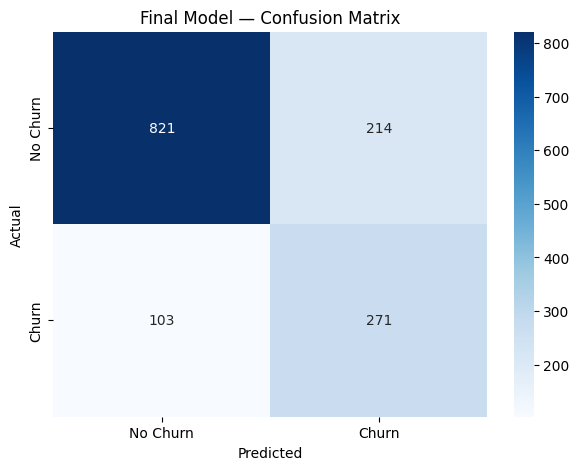

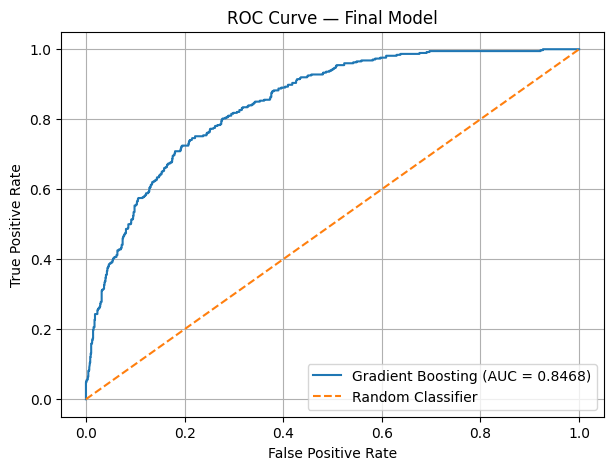

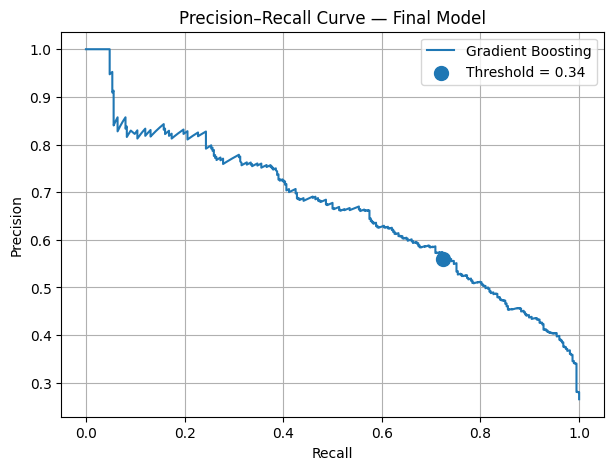

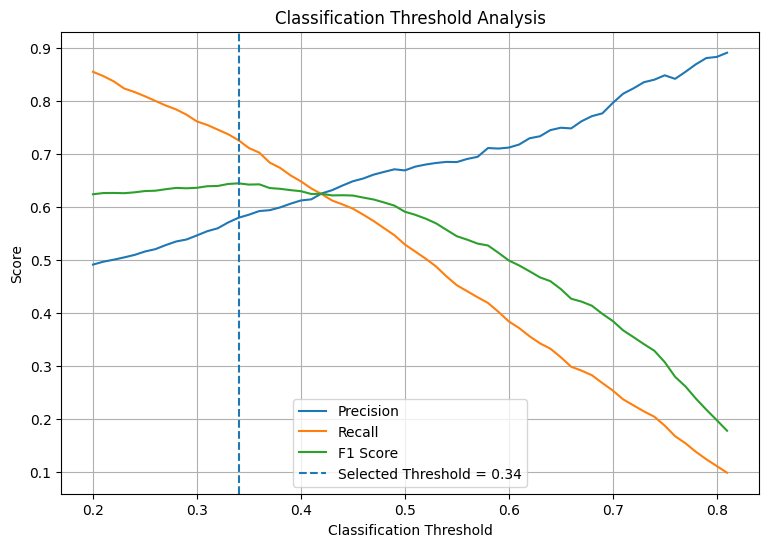

In [37]:
# ============================================================
#  FINAL MODEL VISUAL EVALUATION
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    auc
)


# ============================================================
# 1. CONFUSION MATRIX
# ============================================================

final_cm = confusion_matrix(
    y_test,
    test_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Model — Confusion Matrix")

plt.show()


# ============================================================
# 2. ROC CURVE
# ============================================================

fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    test_probabilities
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Gradient Boosting (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Final Model")

plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 3. PRECISION-RECALL CURVE
# ============================================================

precision_values, recall_values, pr_thresholds = (
    precision_recall_curve(
        y_test,
        test_probabilities
    )
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall_values,
    precision_values,
    label="Gradient Boosting"
)

plt.scatter(
    test_recall,
    test_precision,
    s=100,
    label=f"Threshold = {best_threshold:.2f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Final Model")

plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 4. THRESHOLD VS PRECISION / RECALL / F1
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1"],
    label="F1 Score"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Selected Threshold = {best_threshold:.2f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")

plt.title(
    "Classification Threshold Analysis"
)

plt.legend()
plt.grid(True)

plt.show()

TOP 20 FEATURES — GRADIENT BOOSTING


,Feature,Importance
0,categorical__Contract_Month-to-month,0.3394
1,numerical__tenure,0.1822
2,categorical__InternetService_Fiber optic,0.1155
3,categorical__OnlineSecurity_No,0.0772
4,numerical__MonthlyCharges,0.0577
5,numerical__TotalCharges,0.0556
6,categorical__TechSupport_No,0.0547
7,categorical__PaymentMethod_Electronic check,0.0492
8,categorical__PaperlessBilling_No,0.0104
9,categorical__MultipleLines_No,0.0102


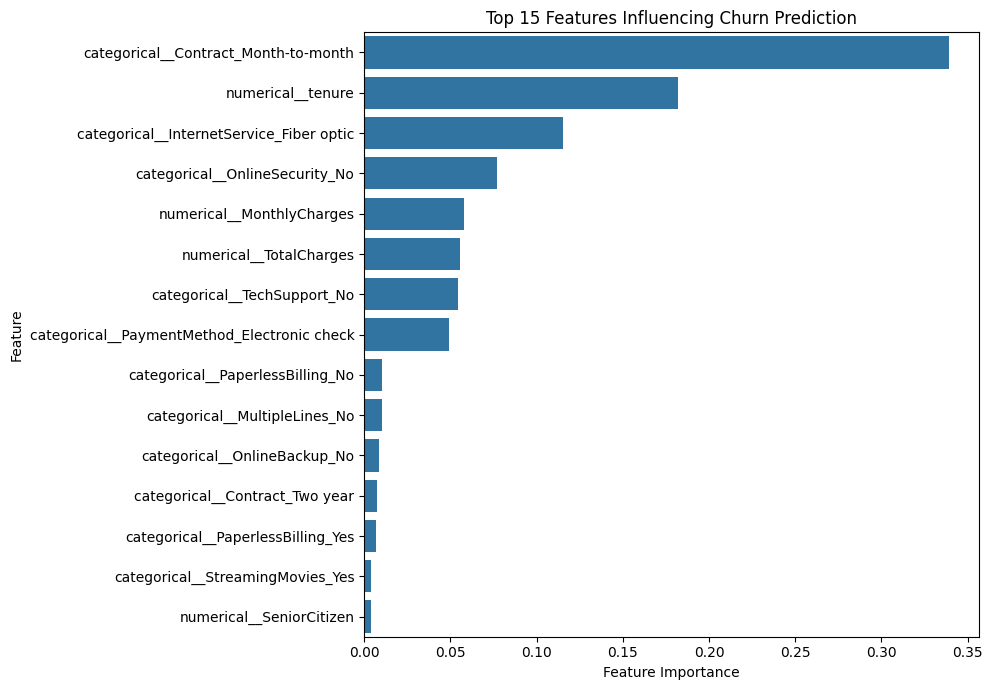

In [38]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ------------------------------------------------------------
# 1. Get the trained Gradient Boosting model
# ------------------------------------------------------------

final_model = gradient_search.best_estimator_

model = final_model.named_steps["model"]
preprocessor_fitted = final_model.named_steps["preprocessor"]


# ------------------------------------------------------------
# 2. Get transformed feature names
# ------------------------------------------------------------

feature_names = preprocessor_fitted.get_feature_names_out()


# ------------------------------------------------------------
# 3. Get feature importance
# ------------------------------------------------------------

importance_values = model.feature_importances_


# ------------------------------------------------------------
# 4. Create feature importance dataframe
# ------------------------------------------------------------

feature_importance = pd.DataFrame({
    
    "Feature": feature_names,
    "Importance": importance_values
    
})


# ------------------------------------------------------------
# 5. Sort features
# ------------------------------------------------------------

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)


# ------------------------------------------------------------
# 6. Display top 20 features
# ------------------------------------------------------------

print("=" * 70)
print("TOP 20 FEATURES — GRADIENT BOOSTING")
print("=" * 70)

display(
    feature_importance
    .head(20)
    .round(4)
)


# ------------------------------------------------------------
# 7. Plot top 15 features
# ------------------------------------------------------------

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Features Influencing Churn Prediction"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

In [39]:
# ============================================================
# CUSTOMER CHURN RISK SEGMENTATION
# ============================================================

# ------------------------------------------------------------
# 1. Create a copy of the TEST SET
# ------------------------------------------------------------

customer_risk = X_test.copy()


# ------------------------------------------------------------
# 2. Add actual churn status
# ------------------------------------------------------------

customer_risk["Actual_Churn"] = y_test.values


# ------------------------------------------------------------
# 3. Add predicted probability
# ------------------------------------------------------------

customer_risk["Churn_Probability"] = test_probabilities


# ------------------------------------------------------------
# 4. Add predicted class
# ------------------------------------------------------------

customer_risk["Predicted_Churn"] = test_predictions


# ------------------------------------------------------------
# 5. Create risk categories
# ------------------------------------------------------------

customer_risk["Risk_Level"] = pd.cut(
    
    customer_risk["Churn_Probability"],
    
    bins=[-np.inf, 0.30, 0.60, np.inf],
    
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)


# ------------------------------------------------------------
# 6. Display risk distribution
# ------------------------------------------------------------

print("=" * 70)
print("CUSTOMER CHURN RISK DISTRIBUTION")
print("=" * 70)

display(
    customer_risk["Risk_Level"]
    .value_counts()
    .to_frame("Customer Count")
)


# ------------------------------------------------------------
# 7. Display high-risk customers
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("HIGH-RISK CUSTOMERS")
print("=" * 70)

display(
    customer_risk[
        customer_risk["Risk_Level"] == "High Risk"
    ]
    .sort_values(
        "Churn_Probability",
        ascending=False
    )
    .head(20)
)

CUSTOMER CHURN RISK DISTRIBUTION


,Customer Count
Risk_Level,
Low Risk,873
Medium Risk,341
High Risk,195



HIGH-RISK CUSTOMERS


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual_Churn,Churn_Probability,Predicted_Churn,Risk_Level
3380,Male,1,Yes,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,95.10,95.10,1,0.932149,1,High Risk
6866,Male,0,No,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,95.45,95.45,1,0.916870,1,High Risk
4585,Female,1,No,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,85.05,85.05,1,0.909181,1,High Risk
2797,Male,0,No,No,3,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,100.95,329.95,1,0.897534,1,High Risk
6623,Male,1,No,No,1,Yes,Yes,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,76.45,76.45,1,0.893151,1,High Risk
2631,Male,1,Yes,No,7,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,99.25,665.45,1,0.892672,1,High Risk
6365,Male,1,Yes,No,7,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,101.95,700.85,1,0.892672,1,High Risk
3727,Female,0,No,No,3,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,96.60,291.90,1,0.877389,1,High Risk
6748,Female,1,No,No,1,Yes,No,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,85.00,85.00,1,0.876344,1,High Risk
2246,Female,0,Yes,Yes,1,Yes,Yes,Fiber optic,Yes,No,...,Yes,Month-to-month,Yes,Electronic check,102.45,102.45,1,0.876012,1,High Risk


In [40]:
# ============================================================
#  GET FINAL MODEL
# ============================================================

final_model = gradient_search.best_estimator_

print(final_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
             

In [41]:
# Get preprocessing part
preprocessor = final_model.named_steps["preprocessor"]

# Get Gradient Boosting model
gb_model = final_model.named_steps["model"]

print(gb_model)

GradientBoostingClassifier(learning_rate=np.float64(0.06411969393171885),
                           max_depth=2, min_samples_split=3, n_estimators=179,
                           random_state=42,
                           subsample=np.float64(0.8233111039954694))


In [42]:
# ============================================================
#  TRANSFORM TEST DATA
# ============================================================

X_test_transformed = preprocessor.transform(X_test)

print("Original test shape:")
print(X_test.shape)

print("\nTransformed test shape:")
print(X_test_transformed.shape)

Original test shape:
(1409, 19)

Transformed test shape:
(1409, 45)


In [43]:
# ============================================================
#  GET TRANSFORMED FEATURE NAMES
# ============================================================

feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))

print("\nFirst 20 features:")

for feature in feature_names[:20]:
    print(feature)

Number of features: 45

First 20 features:
numerical__SeniorCitizen
numerical__tenure
numerical__MonthlyCharges
numerical__TotalCharges
categorical__gender_Female
categorical__gender_Male
categorical__Partner_No
categorical__Partner_Yes
categorical__Dependents_No
categorical__Dependents_Yes
categorical__PhoneService_No
categorical__PhoneService_Yes
categorical__MultipleLines_No
categorical__MultipleLines_No phone service
categorical__MultipleLines_Yes
categorical__InternetService_DSL
categorical__InternetService_Fiber optic
categorical__InternetService_No
categorical__OnlineSecurity_No
categorical__OnlineSecurity_No internet service


In [44]:
# ============================================================
# CREATE SHAP EXPLAINER
# ============================================================

explainer = shap.TreeExplainer(gb_model)

print("SHAP explainer created successfully.")

SHAP explainer created successfully.


In [45]:
# ============================================================
#  CALCULATE SHAP VALUES
# ============================================================

shap_values = explainer.shap_values(
    X_test_transformed
)

print("SHAP values calculated.")

print("SHAP shape:")
print(shap_values.shape)

SHAP values calculated.
SHAP shape:
(1409, 45)


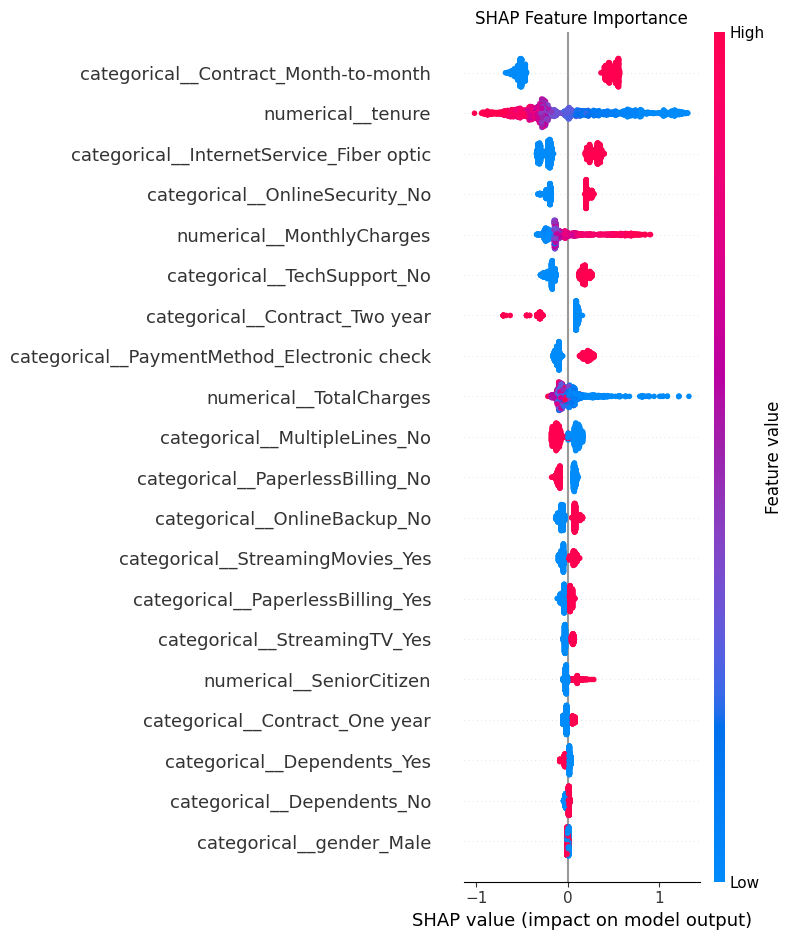

In [46]:
# ============================================================
# GLOBAL SHAP FEATURE IMPORTANCE
# ============================================================

plt.figure()

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    show=False
)

plt.title("SHAP Feature Importance")

plt.tight_layout()

plt.show()

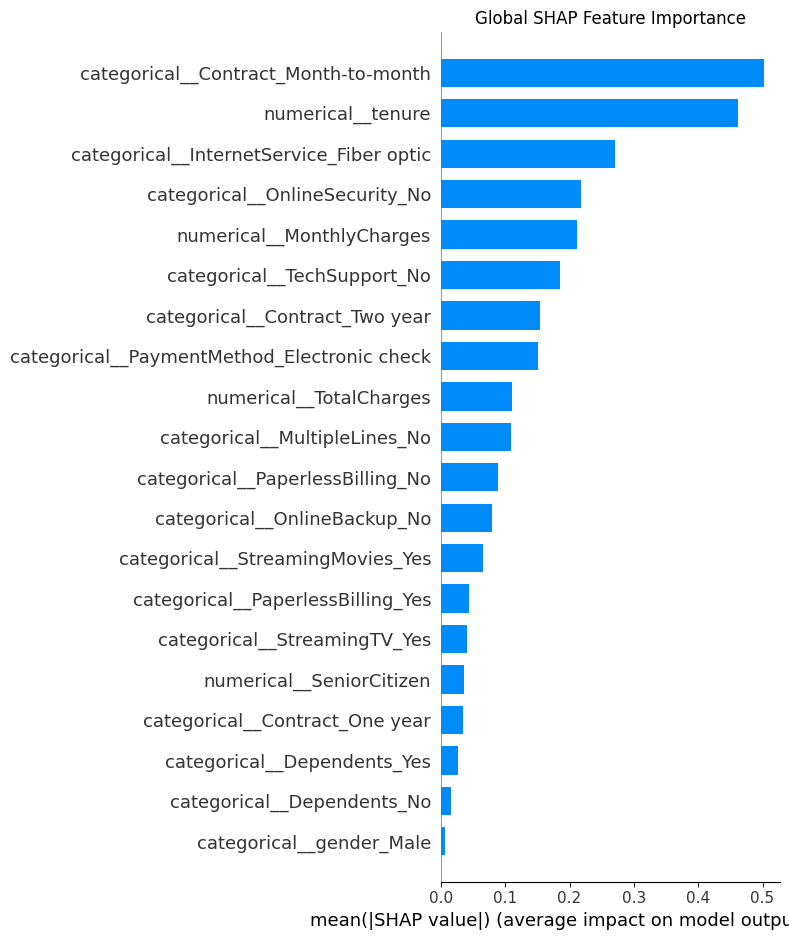

In [47]:
# ============================================================
# SHAP GLOBAL IMPORTANCE BAR PLOT
# ============================================================

plt.figure()

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.title("Global SHAP Feature Importance")

plt.tight_layout()

plt.show()

In [48]:
# ============================================================
# SELECT ONE CUSTOMER
# ============================================================

customer_index = 0

customer_data = X_test.iloc[[customer_index]]

customer_transformed = preprocessor.transform(
    customer_data
)

customer_shap_values = explainer.shap_values(
    customer_transformed
)

print("Customer index:", customer_index)

print(
    "Actual class:",
    y_test.iloc[customer_index]
)

print(
    "Predicted class:",
    test_predictions[customer_index]
)

print(
    "Churn probability:",
    test_probabilities[customer_index]
)

Customer index: 0
Actual class: 0
Predicted class: 0
Churn probability: 0.03390306638381916


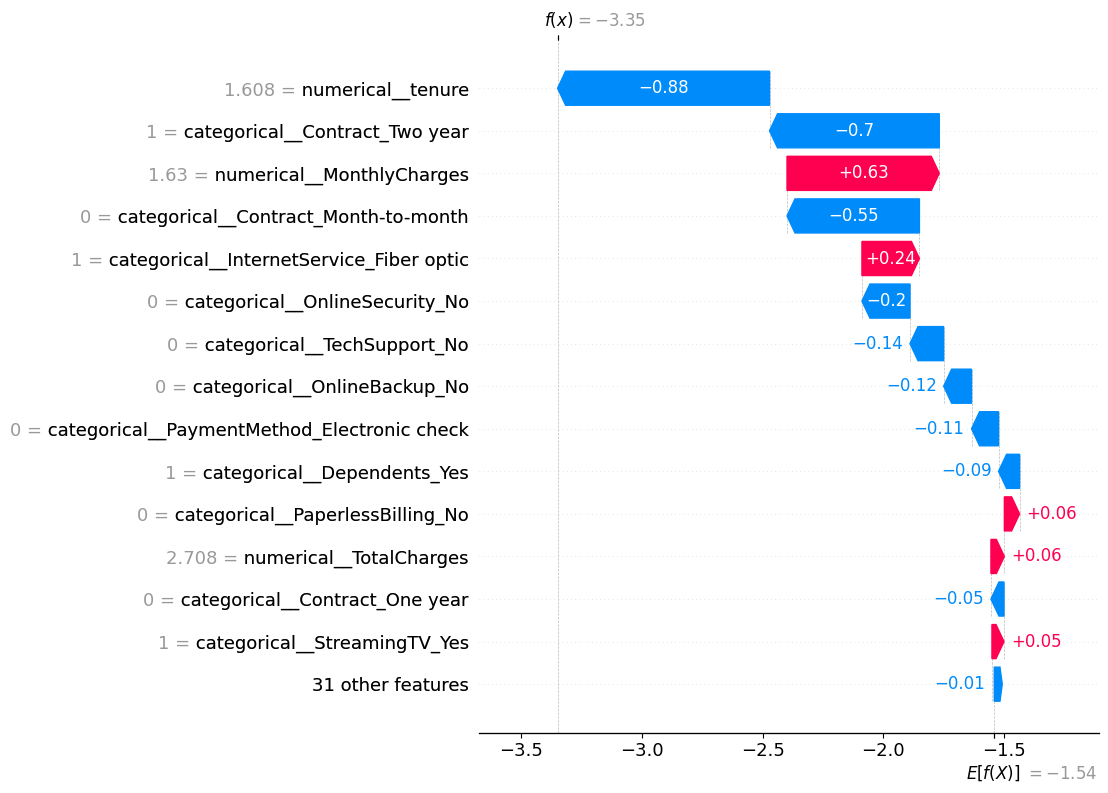

In [49]:
# ============================================================
# INDIVIDUAL CUSTOMER SHAP WATERFALL
# ============================================================

customer_explanation = shap.Explanation(
    values=customer_shap_values[0],
    base_values=explainer.expected_value,
    data=customer_transformed[0],
    feature_names=feature_names
)

shap.plots.waterfall(
    customer_explanation,
    max_display=15
)

In [50]:
# ============================================================
# HIGHEST-RISK CUSTOMER
# ============================================================

highest_risk_index = test_probabilities.argmax()

high_risk_customer = X_test.iloc[[highest_risk_index]]

high_risk_transformed = preprocessor.transform(
    high_risk_customer
)

high_risk_shap = explainer.shap_values(
    high_risk_transformed
)

print("=" * 70)
print("HIGHEST-RISK CUSTOMER")
print("=" * 70)

print(
    "Customer index:",
    highest_risk_index
)

print(
    "Actual class:",
    y_test.iloc[highest_risk_index]
)

print(
    "Predicted class:",
    test_predictions[highest_risk_index]
)

print(
    "Churn probability:",
    test_probabilities[highest_risk_index]
)

HIGHEST-RISK CUSTOMER
Customer index: 1090
Actual class: 1
Predicted class: 1
Churn probability: 0.932149337145592


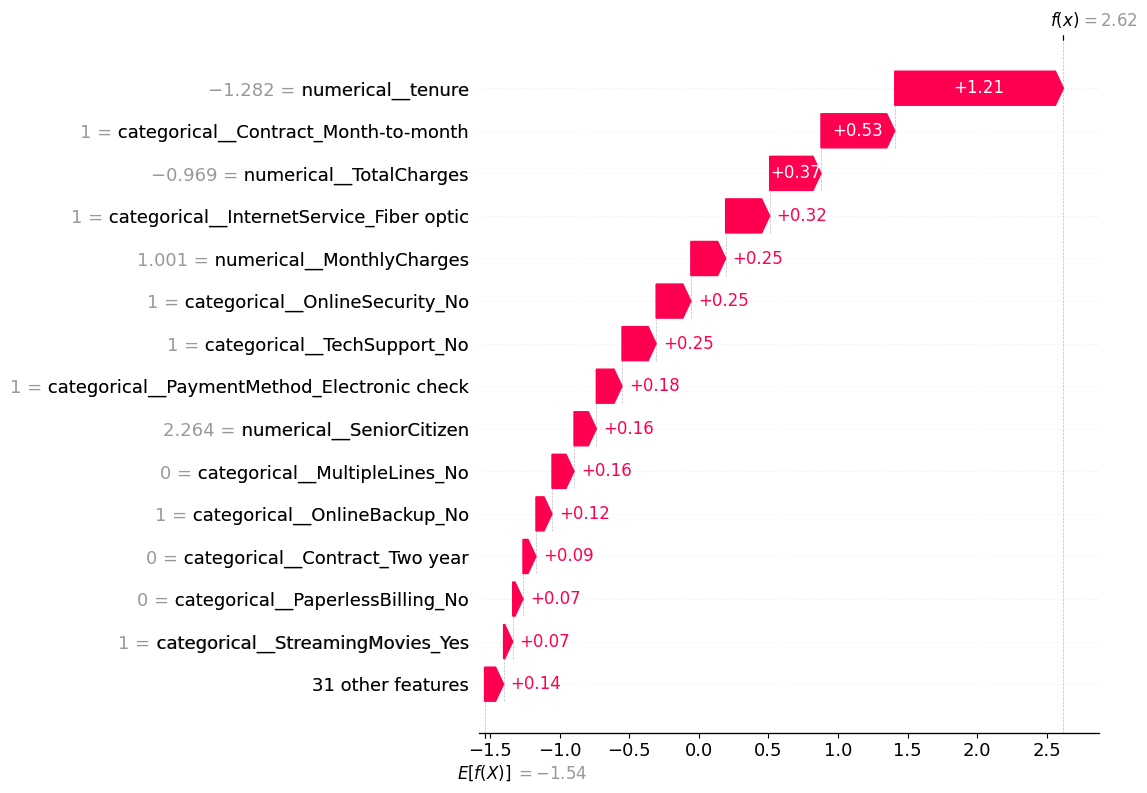

In [51]:
high_risk_explanation = shap.Explanation(
    values=high_risk_shap[0],
    base_values=explainer.expected_value,
    data=high_risk_transformed[0],
    feature_names=feature_names
)

shap.plots.waterfall(
    high_risk_explanation,
    max_display=15
)

In [52]:
# ============================================================
# TOP SHAP FEATURES FOR CUSTOMER
# ============================================================

customer_shap_table = pd.DataFrame({
    "Feature": feature_names,
    "SHAP_Value": customer_shap_values[0],
    "Feature_Value": customer_transformed[0]
})

customer_shap_table["Absolute_SHAP"] = (
    customer_shap_table["SHAP_Value"].abs()
)

customer_shap_table = (
    customer_shap_table
    .sort_values(
        "Absolute_SHAP",
        ascending=False
    )
    .drop(columns="Absolute_SHAP")
)

display(
    customer_shap_table.head(15).round(4)
)

,Feature,SHAP_Value,Feature_Value
1,numerical__tenure,-0.8785,1.6085
38,categorical__Contract_Two year,-0.7037,1.0000
2,numerical__MonthlyCharges,0.6312,1.6300
36,categorical__Contract_Month-to-month,-0.5489,0.0000
16,categorical__InternetService_Fiber optic,0.2383,1.0000
18,categorical__OnlineSecurity_No,-0.1993,0.0000
27,categorical__TechSupport_No,-0.1394,0.0000
21,categorical__OnlineBackup_No,-0.1157,0.0000
43,categorical__PaymentMethod_Electronic check,-0.1119,0.0000
9,categorical__Dependents_Yes,-0.0872,1.0000


In [53]:
# ============================================================
# TOP SHAP FEATURES
# ============================================================

mean_shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": np.abs(shap_values).mean(axis=0)
})

mean_shap_importance = (
    mean_shap_importance
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("TOP SHAP FEATURES")
print("=" * 70)

display(
    mean_shap_importance.head(10).round(4)
)

TOP SHAP FEATURES


,Feature,Mean_Absolute_SHAP
0,categorical__Contract_Month-to-month,0.5021
1,numerical__tenure,0.4616
2,categorical__InternetService_Fiber optic,0.2709
3,categorical__OnlineSecurity_No,0.2177
4,numerical__MonthlyCharges,0.2124
5,categorical__TechSupport_No,0.1850
6,categorical__Contract_Two year,0.1541
7,categorical__PaymentMethod_Electronic check,0.1504
8,numerical__TotalCharges,0.1100
9,categorical__MultipleLines_No,0.1094


Most important feature: categorical__Contract_Month-to-month


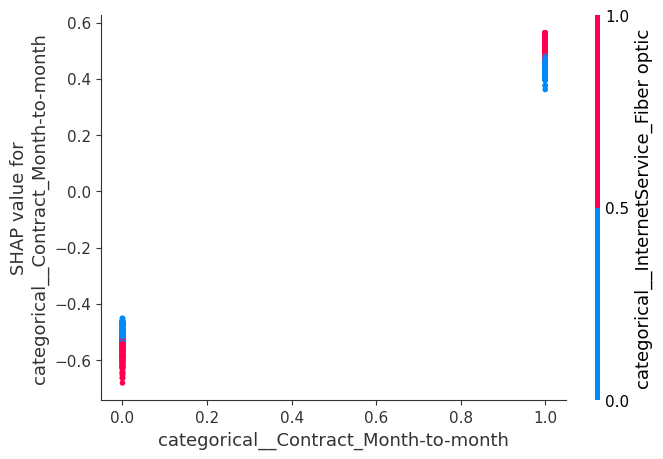

In [54]:
# ============================================================
#  SHAP DEPENDENCE PLOT
# ============================================================

top_feature = mean_shap_importance.iloc[0]["Feature"]

print("Most important feature:", top_feature)

shap.dependence_plot(
    top_feature,
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

In [56]:
# ============================================================
# TOP 5 SHAP DEPENDENCE PLOTS
# ============================================================

top_5_features = (
    mean_shap_importance
    .head(5)["Feature"]
    .tolist()
)

print("Top 5 features:")

for feature in top_5_features:
    print("-", feature)

Top 5 features:
- categorical__Contract_Month-to-month
- numerical__tenure
- categorical__InternetService_Fiber optic
- categorical__OnlineSecurity_No
- numerical__MonthlyCharges



SHAP DEPENDENCE: categorical__Contract_Month-to-month


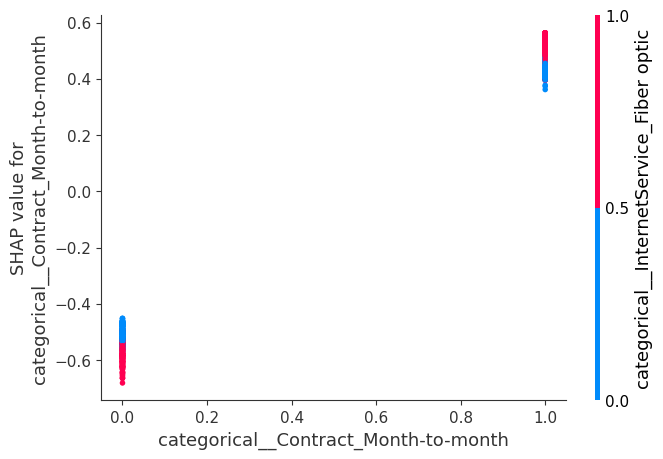


SHAP DEPENDENCE: numerical__tenure


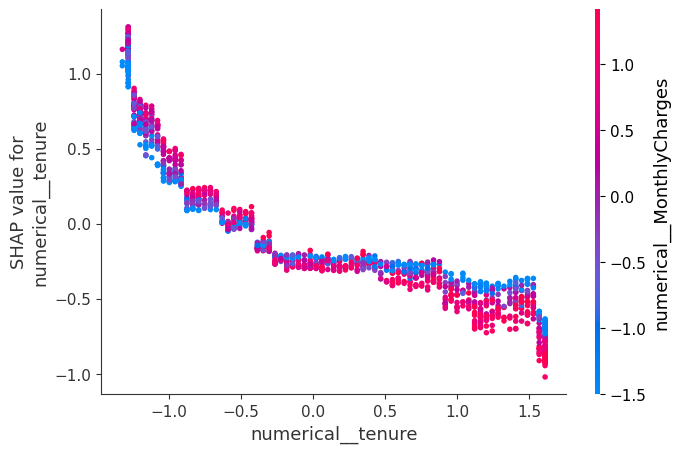


SHAP DEPENDENCE: categorical__InternetService_Fiber optic


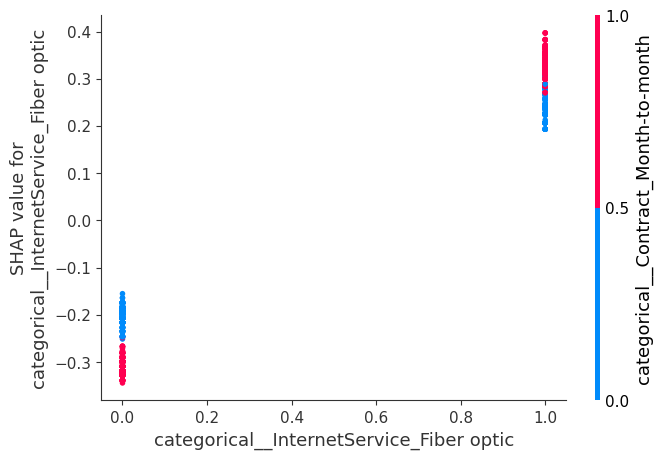


SHAP DEPENDENCE: categorical__OnlineSecurity_No


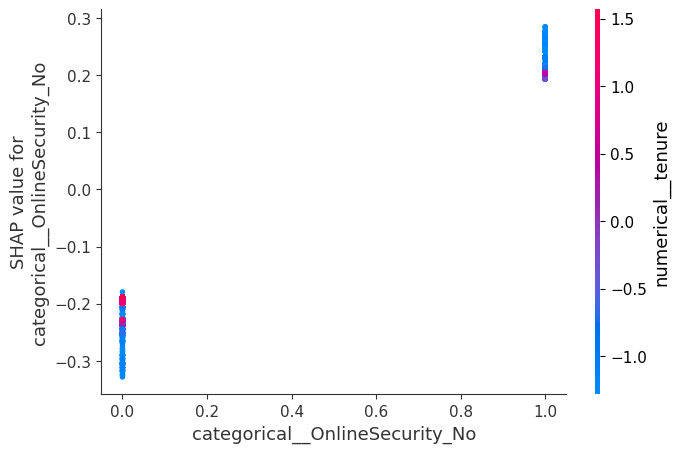


SHAP DEPENDENCE: numerical__MonthlyCharges


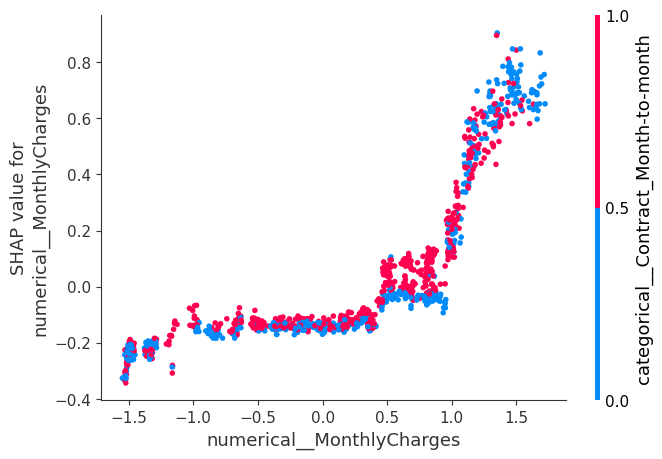

In [57]:
for feature in top_5_features:

    print("\n" + "=" * 70)
    print("SHAP DEPENDENCE:", feature)
    print("=" * 70)

    shap.dependence_plot(
        feature,
        shap_values,
        X_test_transformed,
        feature_names=feature_names
    )

In [58]:
import numpy
import pandas
import sklearn
import matplotlib
import seaborn
import shap

print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", seaborn.__version__)
print("shap:", shap.__version__)

numpy: 2.3.5
pandas: 2.3.3
scikit-learn: 1.9.0
matplotlib: 3.10.8
seaborn: 0.13.2
shap: 0.52.0
